# Project 3 — Dataset 4: Online Retail Transactions

## Kernel and Non-Kernel Learning Under Real-World Data Imperfections

This notebook implements the complete pipeline for **Dataset 4: Online Retail Transactions**.

According to the assignment, this dataset requires a different strategy from Airbnb, NYC 311, and HR Attrition. The raw data is not already one row per prediction instance. It is a **transaction-level log**, so the central data engineering requirement is to transform raw invoice lines into **customer-level behavioral features** before modeling.

The two prediction tasks are:

1. **Customer Segment Classification**  
   Predict a future customer-value segment from historical purchasing behavior.

2. **Future Spending Regression**  
   Predict how much a customer will spend in a future period.

The notebook includes:

- Data loading and schema inspection
- Transaction-level data quality investigation
- Missingness analysis and MCAR/MAR/MNAR reasoning
- Duplicate, cancellation, and invalid-value handling
- Transition from transaction-level logs to customer-level features
- Customer segmentation target construction without feature leakage
- Outlier analysis using Z-score, IQR, and a NumPy-only Simple Isolation Forest
- Feature quality analysis: redundancy, leakage, near-constant features
- From-scratch preprocessing and train/test split
- Non-kernel models from scratch
- Kernel methods from scratch
- Failure analysis, bias discussion, computational analysis, and report-ready conclusions

In [1]:
# ============================================================
# Section 0: Project Setup
# ============================================================

import os
import re
import time
import math
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 240)

OUTPUT_DIR = Path("outputs_online_retail")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")
print(f"Random seed fixed at: {RANDOM_STATE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Libraries imported successfully.
Random seed fixed at: 42
Output directory: C:\Users\Administrator\Desktop\ML Projects\dataset4\outputs_online_retail


## 1. Loading the Online Retail Dataset

The Online Retail dataset is stored as an Excel file. The expected raw columns are:

- `InvoiceNo`
- `StockCode`
- `Description`
- `Quantity`
- `InvoiceDate`
- `UnitPrice`
- `CustomerID`
- `Country`

This dataset is a transaction log. A single customer may have many invoices, and each invoice may contain many product lines. Therefore, we cannot directly train customer-level models on the raw rows. We first inspect the raw transactional data and then aggregate it into customer-level behavioral features.

In [2]:
# ============================================================
# Section 1: Load Online Retail Dataset
# ============================================================

DATA_PATH_CANDIDATES = [
    Path("Online Retail(1).xlsx"),
    Path("Online Retail.xlsx"),
    Path("./Online Retail(1).xlsx"),
    Path("./Online Retail.xlsx"),
    Path("../Online Retail(1).xlsx"),
    Path("../Online Retail.xlsx"),
    Path("/mnt/data/Online Retail(1).xlsx"),
    Path("/mnt/data/Online Retail.xlsx")
]

DATA_PATH = None
for candidate_path in DATA_PATH_CANDIDATES:
    if candidate_path.exists():
        DATA_PATH = candidate_path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Online Retail Excel file was not found. Please place `Online Retail(1).xlsx` or "
        "`Online Retail.xlsx` in the notebook folder, or update DATA_PATH_CANDIDATES."
    )

excel_file = pd.ExcelFile(DATA_PATH)
print("Excel file loaded successfully.")
print(f"Path: {DATA_PATH}")
print("Sheet names:", excel_file.sheet_names)

sheet_name = excel_file.sheet_names[0]
df_raw = pd.read_excel(DATA_PATH, sheet_name=sheet_name)

print("Dataset loaded successfully.")
print(f"Number of rows: {df_raw.shape[0]:,}")
print(f"Number of columns: {df_raw.shape[1]}")

display(df_raw.head())

Excel file loaded successfully.
Path: Online Retail.xlsx
Sheet names: ['Online Retail']
Dataset loaded successfully.
Number of rows: 541,909
Number of columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Basic Schema Inspection

Before cleaning, we inspect the raw schema. This allows us to detect:

- Mixed data types
- Missing values
- High-cardinality identifiers
- Transactional fields
- Customer identifier availability
- Date column validity

This step is important because later modeling must happen at the customer level, not directly at the transaction-line level.

In [3]:
# ============================================================
# Section 2: Basic Schema Inspection
# ============================================================

print("Column names:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {col}")

schema_table = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "non_null_count": df_raw.notna().sum().values,
    "missing_count": df_raw.isna().sum().values,
    "missing_rate": df_raw.isna().mean().values,
    "unique_values": df_raw.nunique(dropna=False).values,
    "unique_rate": [df_raw[col].nunique(dropna=False) / len(df_raw) for col in df_raw.columns]
}).sort_values("missing_rate", ascending=False).reset_index(drop=True)

display(schema_table)
print("Data type counts:")
display(df_raw.dtypes.value_counts())

Column names:
01. InvoiceNo
02. StockCode
03. Description
04. Quantity
05. InvoiceDate
06. UnitPrice
07. CustomerID
08. Country


,column,dtype,non_null_count,missing_count,missing_rate,unique_values,unique_rate
0,CustomerID,float64,406829,135080,0.249267,4373,0.008070
1,Description,object,540455,1454,0.002683,4224,0.007795
2,StockCode,object,541909,0,0.000000,4070,0.007510
3,InvoiceNo,object,541909,0,0.000000,25900,0.047794
4,Quantity,int64,541909,0,0.000000,722,0.001332
5,InvoiceDate,datetime64[ns],541909,0,0.000000,23260,0.042922
6,UnitPrice,float64,541909,0,0.000000,1630,0.003008
7,Country,object,541909,0,0.000000,38,0.000070


Data type counts:


object            4
float64           2
int64             1
datetime64[ns]    1
Name: count, dtype: int64

## 3. Assignment-Specific Problem Definition

For Online Retail, the assignment requires moving from raw transaction logs to **customer-level behavioral features**.

We define a production-like temporal setup:

- Historical period: used to build customer features.
- Future period: used to define the labels.

This prevents leakage because future spending and future segment labels are not used as input features.

Targets:

1. `future_spending`: total amount spent by the customer in the future period.
2. `future_customer_segment`: customer-value segment derived from future behavior.

The classification target is not created from the same historical features used as inputs. Instead, it represents future customer value, which is what a business would want to predict.

In [4]:
# ============================================================
# Section 3: Problem Definition Helpers
# ============================================================

required_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]

missing_required = [col for col in required_columns if col not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns are present.")
print("Raw task: transaction-level log -> customer-level supervised learning dataset.")

All required columns are present.
Raw task: transaction-level log -> customer-level supervised learning dataset.


## 4. Initial Transaction-Level Data Quality Flags

The Online Retail data contains real-world transaction imperfections.

Important examples:

- Missing `CustomerID`
- Missing product `Description`
- Negative `Quantity`, often representing returns or cancellations
- `InvoiceNo` starting with `C`, often representing cancellations
- Zero or negative `UnitPrice`
- Duplicated invoice lines
- Non-product stock codes such as postage or manual adjustments

We do not remove everything immediately. Instead, we create diagnostic flags first so the report can explain the cleaning decisions.

In [5]:
# ============================================================
# Section 4: Initial Transaction-Level Data Quality Flags
# ============================================================

df = df_raw.copy()

# Standardize column types for analysis.
df["InvoiceNo_str"] = df["InvoiceNo"].astype(str)
df["StockCode_str"] = df["StockCode"].astype(str)
df["Description_str"] = df["Description"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Transaction diagnostics.
df["is_cancel_invoice"] = df["InvoiceNo_str"].str.startswith("C").astype(int)
df["is_negative_quantity"] = (pd.to_numeric(df["Quantity"], errors="coerce") < 0).astype(int)
df["is_nonpositive_quantity"] = (pd.to_numeric(df["Quantity"], errors="coerce") <= 0).astype(int)
df["is_nonpositive_unitprice"] = (pd.to_numeric(df["UnitPrice"], errors="coerce") <= 0).astype(int)
df["has_customer_id"] = df["CustomerID"].notna().astype(int)
df["has_description"] = df["Description"].notna().astype(int)
df["description_length"] = df["Description"].fillna("").astype(str).str.len()
df["line_value"] = pd.to_numeric(df["Quantity"], errors="coerce") * pd.to_numeric(df["UnitPrice"], errors="coerce")
df["line_value_abs"] = df["line_value"].abs()

# Some StockCodes in this dataset are operational codes rather than ordinary product codes.
special_stockcode_pattern = r"^(POST|DOT|M|BANK CHARGES|AMAZONFEE|CRUK|D|S|C2)$"
df["is_special_stockcode"] = df["StockCode_str"].str.upper().str.match(special_stockcode_pattern, na=False).astype(int)

quality_summary = pd.DataFrame({
    "quality_flag": [
        "missing_customer_id",
        "missing_description",
        "cancel_invoice",
        "negative_quantity",
        "nonpositive_quantity",
        "nonpositive_unitprice",
        "special_stockcode"
    ],
    "count": [
        df["CustomerID"].isna().sum(),
        df["Description"].isna().sum(),
        df["is_cancel_invoice"].sum(),
        df["is_negative_quantity"].sum(),
        df["is_nonpositive_quantity"].sum(),
        df["is_nonpositive_unitprice"].sum(),
        df["is_special_stockcode"].sum()
    ]
})
quality_summary["rate"] = quality_summary["count"] / len(df)

display(quality_summary)
display(df.head())

,quality_flag,count,rate
0,missing_customer_id,135080,0.249267
1,missing_description,1454,0.002683
2,cancel_invoice,9288,0.017139
3,negative_quantity,10624,0.019605
4,nonpositive_quantity,10624,0.019605
5,nonpositive_unitprice,2517,0.004645
6,special_stockcode,2909,0.005368


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo_str,StockCode_str,Description_str,is_cancel_invoice,is_negative_quantity,is_nonpositive_quantity,is_nonpositive_unitprice,has_customer_id,has_description,description_length,line_value,line_value_abs,is_special_stockcode
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0,0,0,0,1,1,34,15.30,15.30,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365,71053,WHITE METAL LANTERN,0,0,0,0,1,1,19,20.34,20.34,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,536365,84406B,CREAM CUPID HEARTS COAT HANGER,0,0,0,0,1,1,30,22.00,22.00,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,0,0,0,0,1,1,35,20.34,20.34,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,0,0,0,0,1,1,30,20.34,20.34,0


## 5. Missing Value Analysis

The assignment requires missing data analysis and reasoning about MCAR, MAR, and MNAR.

For Online Retail:

- Missing `CustomerID` is usually not random because some transactions may not be linked to registered customers.
- Missing `Description` can be related to special stock codes, operational records, or data-entry problems.
- Missing dates or prices would be severe because they directly affect temporal splitting and monetary features.

We first summarize missingness at the transaction level.

,column,dtype,missing_count,missing_rate,unique_values,missing_group
0,CustomerID,float64,135080,0.249267,4373,Moderate missingness
1,Description,object,1454,0.002683,4224,Low missingness
2,InvoiceNo,object,0,0.000000,25900,No missing
3,Quantity,int64,0,0.000000,722,No missing
4,StockCode,object,0,0.000000,4070,No missing
5,InvoiceDate,datetime64[ns],0,0.000000,23260,No missing
6,UnitPrice,float64,0,0.000000,1630,No missing
7,Country,object,0,0.000000,38,No missing
8,InvoiceNo_str,object,0,0.000000,25900,No missing
9,StockCode_str,object,0,0.000000,4070,No missing


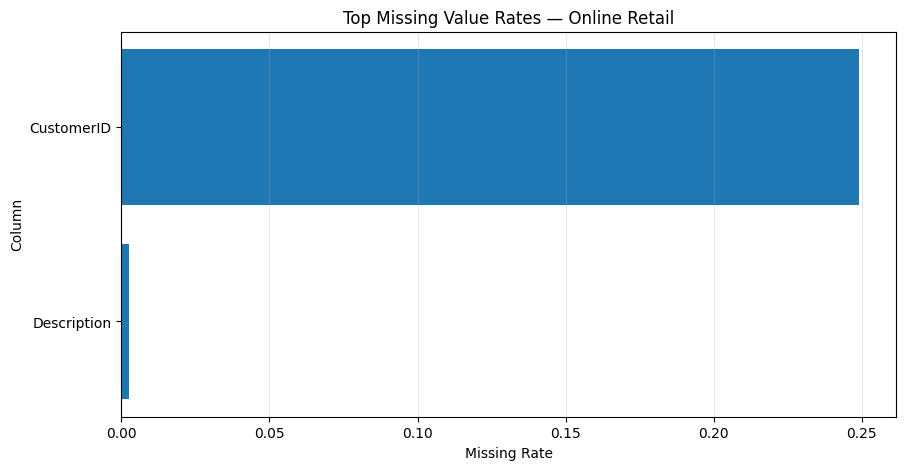

In [6]:
# ============================================================
# Section 5: Missing Value Analysis
# ============================================================

missing_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_rate": df.isna().mean().values,
    "unique_values": df.nunique(dropna=False).values
})

def missing_group(rate):
    if rate == 0:
        return "No missing"
    elif rate <= 0.05:
        return "Low missingness"
    elif rate <= 0.30:
        return "Moderate missingness"
    elif rate < 1.0:
        return "High missingness"
    return "Completely missing"

missing_summary["missing_group"] = missing_summary["missing_rate"].apply(missing_group)
missing_summary = missing_summary.sort_values("missing_rate", ascending=False).reset_index(drop=True)

display(missing_summary)

plt.figure(figsize=(10, 5))
top_missing = missing_summary[missing_summary["missing_rate"] > 0].head(20)
plt.barh(top_missing["column"][::-1], top_missing["missing_rate"][::-1])
plt.xlabel("Missing Rate")
plt.ylabel("Column")
plt.title("Top Missing Value Rates — Online Retail")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 6. Missingness Mechanism Evidence

We test whether missingness indicators are associated with observed transaction variables.

This does not fully prove MCAR/MAR/MNAR, but it provides evidence.

- If missingness is associated with observed features, it is more consistent with MAR.
- If missingness has no observed association, it may be approximately MCAR.
- If domain reasoning suggests hidden behavior or unobserved causes, we mark it as suspected MNAR.

In [7]:
# ============================================================
# Section 6: Missingness Mechanism Evidence
# ============================================================

important_missing_cols = [
    "CustomerID", "Description", "InvoiceDate", "UnitPrice", "Quantity", "Country", "StockCode"
]
important_missing_cols = [c for c in important_missing_cols if c in df.columns]

for col in important_missing_cols:
    if df[col].isna().sum() > 0:
        df[f"is_missing__{col}"] = df[col].isna().astype(int)

missing_indicators = [c for c in df.columns if c.startswith("is_missing__")]

numeric_explainers = [
    "Quantity", "UnitPrice", "line_value", "line_value_abs",
    "description_length", "is_cancel_invoice", "is_negative_quantity",
    "is_special_stockcode"
]
numeric_explainers = [c for c in numeric_explainers if c in df.columns]

categorical_explainers = ["Country", "StockCode_str"]
categorical_explainers = [c for c in categorical_explainers if c in df.columns]

association_rows = []

for miss_col in missing_indicators:
    original_col = miss_col.replace("is_missing__", "")
    for num_col in numeric_explainers:
        temp = df[[miss_col, num_col]].dropna()
        if temp[miss_col].nunique() < 2:
            continue
        g0 = temp.loc[temp[miss_col] == 0, num_col]
        g1 = temp.loc[temp[miss_col] == 1, num_col]
        if len(g0) < 20 or len(g1) < 20:
            continue
        try:
            stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
            association_rows.append({
                "missing_column": original_col,
                "missing_indicator": miss_col,
                "explainer": num_col,
                "test": "Mann-Whitney U",
                "p_value": p,
                "observed_group_median": g0.median(),
                "missing_group_median": g1.median()
            })
        except Exception:
            pass

    for cat_col in categorical_explainers:
        temp = df[[miss_col, cat_col]].dropna().copy()
        if temp[miss_col].nunique() < 2:
            continue
        if temp[cat_col].nunique() > 30:
            top = temp[cat_col].value_counts().head(30).index
            temp[cat_col] = np.where(temp[cat_col].isin(top), temp[cat_col], "OTHER")
        contingency = pd.crosstab(temp[miss_col], temp[cat_col])
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            try:
                chi2, p, dof, expected = stats.chi2_contingency(contingency)
                association_rows.append({
                    "missing_column": original_col,
                    "missing_indicator": miss_col,
                    "explainer": cat_col,
                    "test": "Chi-square",
                    "p_value": p,
                    "observed_group_median": np.nan,
                    "missing_group_median": np.nan
                })
            except Exception:
                pass

missingness_association_table = pd.DataFrame(association_rows)
if len(missingness_association_table) > 0:
    missingness_association_table = missingness_association_table.sort_values("p_value").reset_index(drop=True)

def classify_missingness_online_retail(column):
    if column == "CustomerID":
        return "MAR / Suspected MNAR"
    if column == "Description":
        return "MAR"
    if column in ["InvoiceDate", "UnitPrice", "Quantity"]:
        return "Critical field; investigate, usually data-entry/system issue"
    return "Approximately MCAR or unclear"

missingness_classification = missing_summary.copy()
missingness_classification["missingness_mechanism"] = missingness_classification["column"].apply(classify_missingness_online_retail)

display(missingness_association_table.head(80))
display(missingness_classification)

,missing_column,missing_indicator,explainer,test,p_value,observed_group_median,missing_group_median
0,CustomerID,is_missing__CustomerID,Quantity,Mann-Whitney U,0.000000e+00,5.00,1.00
1,CustomerID,is_missing__CustomerID,UnitPrice,Mann-Whitney U,0.000000e+00,1.95,3.29
2,CustomerID,is_missing__CustomerID,line_value,Mann-Whitney U,0.000000e+00,11.10,4.96
3,CustomerID,is_missing__CustomerID,line_value_abs,Mann-Whitney U,0.000000e+00,11.80,4.96
4,CustomerID,is_missing__CustomerID,is_cancel_invoice,Mann-Whitney U,0.000000e+00,0.00,0.00
5,Description,is_missing__Description,UnitPrice,Mann-Whitney U,0.000000e+00,2.08,0.00
6,CustomerID,is_missing__CustomerID,StockCode_str,Chi-square,0.000000e+00,NaN,NaN
7,CustomerID,is_missing__CustomerID,Country,Chi-square,0.000000e+00,NaN,NaN
8,Description,is_missing__Description,description_length,Mann-Whitney U,0.000000e+00,27.00,0.00
9,Description,is_missing__Description,line_value_abs,Mann-Whitney U,0.000000e+00,9.90,0.00


,column,dtype,missing_count,missing_rate,unique_values,missing_group,missingness_mechanism
0,CustomerID,float64,135080,0.249267,4373,Moderate missingness,MAR / Suspected MNAR
1,Description,object,1454,0.002683,4224,Low missingness,MAR
2,InvoiceNo,object,0,0.000000,25900,No missing,Approximately MCAR or unclear
3,Quantity,int64,0,0.000000,722,No missing,"Critical field; investigate, usually data-entr..."
4,StockCode,object,0,0.000000,4070,No missing,Approximately MCAR or unclear
5,InvoiceDate,datetime64[ns],0,0.000000,23260,No missing,"Critical field; investigate, usually data-entr..."
6,UnitPrice,float64,0,0.000000,1630,No missing,"Critical field; investigate, usually data-entr..."
7,Country,object,0,0.000000,38,No missing,Approximately MCAR or unclear
8,InvoiceNo_str,object,0,0.000000,25900,No missing,Approximately MCAR or unclear
9,StockCode_str,object,0,0.000000,4070,No missing,Approximately MCAR or unclear


## 7. Duplicate and Cancellation Analysis

Transaction logs can contain duplicated lines and cancellation records.

For this dataset:

- Exact duplicate rows may overweight certain purchases.
- Cancellation invoices should not be mixed with valid purchases for spending prediction.
- Negative quantities often represent returns.

We document these records first, then create a clean sales dataset for customer-level modeling.

In [8]:
# ============================================================
# Section 7: Duplicate and Cancellation Analysis
# ============================================================

exact_duplicate_count = df.duplicated().sum()

line_key_columns = ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
line_key_columns = [c for c in line_key_columns if c in df.columns]
near_duplicate_count = df.duplicated(subset=line_key_columns).sum()

invoice_summary = df.groupby("InvoiceNo_str").agg(
    line_count=("StockCode_str", "size"),
    unique_products=("StockCode_str", "nunique"),
    invoice_value=("line_value", "sum"),
    customer_id_count=("CustomerID", "nunique"),
    is_cancel_invoice=("is_cancel_invoice", "max")
).reset_index()

cancellation_summary = pd.DataFrame({
    "metric": [
        "exact_duplicate_rows",
        "near_duplicate_rows_by_line_key",
        "cancel_invoice_rows",
        "negative_quantity_rows",
        "valid_positive_sales_rows"
    ],
    "value": [
        exact_duplicate_count,
        near_duplicate_count,
        int(df["is_cancel_invoice"].sum()),
        int(df["is_negative_quantity"].sum()),
        int(((df["Quantity"] > 0) & (df["UnitPrice"] > 0) & (df["CustomerID"].notna()) & (df["is_cancel_invoice"] == 0)).sum())
    ]
})

cancellation_summary["rate"] = cancellation_summary["value"] / len(df)

display(cancellation_summary)
display(invoice_summary.head())

,metric,value,rate
0,exact_duplicate_rows,5268,0.009721
1,near_duplicate_rows_by_line_key,5268,0.009721
2,cancel_invoice_rows,9288,0.017139
3,negative_quantity_rows,10624,0.019605
4,valid_positive_sales_rows,397884,0.734227


,InvoiceNo_str,line_count,unique_products,invoice_value,customer_id_count,is_cancel_invoice
0,536365,7,7,139.12,1,0
1,536366,2,2,22.20,1,0
2,536367,12,12,278.73,1,0
3,536368,4,4,70.05,1,0
4,536369,1,1,17.85,1,0


## 8. Clean Transaction Dataset for Customer Modeling

For customer-level modeling, we use valid purchase transactions only.

Cleaning rules:

- Keep rows with known `CustomerID`.
- Keep positive `Quantity`.
- Keep positive `UnitPrice`.
- Remove cancellation invoices.
- Remove exact duplicate rows.
- Compute `line_value = Quantity * UnitPrice`.

We preserve cancellation and invalid-row statistics in the report, but they are not used to construct customer spending targets.

In [9]:
# ============================================================
# Section 8: Clean Transaction Dataset for Customer Modeling
# ============================================================

df_sales = df.copy()

before_rows = len(df_sales)

df_sales = df_sales.drop_duplicates().copy()
after_dedup_rows = len(df_sales)

valid_sales_mask = (
    df_sales["CustomerID"].notna()
    & df_sales["InvoiceDate"].notna()
    & (pd.to_numeric(df_sales["Quantity"], errors="coerce") > 0)
    & (pd.to_numeric(df_sales["UnitPrice"], errors="coerce") > 0)
    & (df_sales["is_cancel_invoice"] == 0)
)

df_sales = df_sales.loc[valid_sales_mask].copy()
df_sales["CustomerID"] = df_sales["CustomerID"].astype(int)
df_sales["Quantity"] = pd.to_numeric(df_sales["Quantity"], errors="coerce")
df_sales["UnitPrice"] = pd.to_numeric(df_sales["UnitPrice"], errors="coerce")
df_sales["line_value"] = df_sales["Quantity"] * df_sales["UnitPrice"]

df_sales["invoice_date_only"] = df_sales["InvoiceDate"].dt.date
df_sales["invoice_year"] = df_sales["InvoiceDate"].dt.year
df_sales["invoice_month"] = df_sales["InvoiceDate"].dt.month
df_sales["invoice_dayofweek"] = df_sales["InvoiceDate"].dt.dayofweek
df_sales["invoice_hour"] = df_sales["InvoiceDate"].dt.hour

dataset_cleaning_summary = pd.DataFrame({
    "step": [
        "raw_rows",
        "after_exact_duplicate_removal",
        "valid_customer_positive_sales"
    ],
    "rows": [before_rows, after_dedup_rows, len(df_sales)]
})
dataset_cleaning_summary["removed_from_previous_step"] = dataset_cleaning_summary["rows"].shift(1) - dataset_cleaning_summary["rows"]
dataset_cleaning_summary["remaining_rate_vs_raw"] = dataset_cleaning_summary["rows"] / before_rows

display(dataset_cleaning_summary)
print("Clean sales date range:")
print(df_sales["InvoiceDate"].min(), "to", df_sales["InvoiceDate"].max())
print("Number of unique customers:", df_sales["CustomerID"].nunique())
display(df_sales.head())

,step,rows,removed_from_previous_step,remaining_rate_vs_raw
0,raw_rows,541909,NaN,1.000000
1,after_exact_duplicate_removal,536641,5268.0,0.990279
2,valid_customer_positive_sales,392692,143949.0,0.724646


Clean sales date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00
Number of unique customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo_str,StockCode_str,Description_str,is_cancel_invoice,is_negative_quantity,is_nonpositive_quantity,is_nonpositive_unitprice,has_customer_id,has_description,description_length,line_value,line_value_abs,is_special_stockcode,is_missing__CustomerID,is_missing__Description,invoice_date_only,invoice_year,invoice_month,invoice_dayofweek,invoice_hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0,0,0,0,1,1,34,15.30,15.30,0,0,0,2010-12-01,2010,12,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,536365,71053,WHITE METAL LANTERN,0,0,0,0,1,1,19,20.34,20.34,0,0,0,2010-12-01,2010,12,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,536365,84406B,CREAM CUPID HEARTS COAT HANGER,0,0,0,0,1,1,30,22.00,22.00,0,0,0,2010-12-01,2010,12,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,0,0,0,0,1,1,35,20.34,20.34,0,0,0,2010-12-01,2010,12,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,0,0,0,0,1,1,30,20.34,20.34,0,0,0,2010-12-01,2010,12,2,8


## 9. Temporal Train Label Design

To avoid leakage, we define customer features from a historical window and labels from a future window.

The future window is the last 90 days of the dataset.

- Historical features: transactions before the cutoff date.
- Future target: spending after the cutoff date.

This simulates a realistic business problem: using past behavior to predict future value.

In [10]:
# ============================================================
# Section 9: Temporal Cutoff for Future Spending Target
# ============================================================

max_date = df_sales["InvoiceDate"].max()
min_date = df_sales["InvoiceDate"].min()
future_window_days = 90
cutoff_date = max_date - pd.Timedelta(days=future_window_days)

history_df = df_sales[df_sales["InvoiceDate"] < cutoff_date].copy()
future_df = df_sales[df_sales["InvoiceDate"] >= cutoff_date].copy()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")
print(f"Cutoff date:  {cutoff_date}")
print(f"History rows: {len(history_df):,}")
print(f"Future rows:  {len(future_df):,}")
print(f"History customers: {history_df['CustomerID'].nunique():,}")
print(f"Future customers:  {future_df['CustomerID'].nunique():,}")

split_summary = pd.DataFrame({
    "period": ["history", "future"],
    "start_date": [history_df["InvoiceDate"].min(), future_df["InvoiceDate"].min()],
    "end_date": [history_df["InvoiceDate"].max(), future_df["InvoiceDate"].max()],
    "rows": [len(history_df), len(future_df)],
    "unique_customers": [history_df["CustomerID"].nunique(), future_df["CustomerID"].nunique()],
    "total_sales": [history_df["line_value"].sum(), future_df["line_value"].sum()]
})

display(split_summary)

Minimum date: 2010-12-01 08:26:00
Maximum date: 2011-12-09 12:50:00
Cutoff date:  2011-09-10 12:50:00
History rows: 233,840
Future rows:  158,852
History customers: 3,370
Future customers:  2,889


,period,start_date,end_date,rows,unique_customers,total_sales
0,history,2010-12-01 08:26:00,2011-09-09 15:53:00,233840,3370,5442978.642
1,future,2011-09-11 10:35:00,2011-12-09 12:50:00,158852,2889,3444230.252


## 10. Transaction-Level Feature Engineering Before Aggregation

Before aggregating to customers, we create transaction-level behavioral features that can later be summarized.

Examples:

- Weekend purchase indicator
- After-hours purchase indicator
- Invoice-level basket value
- Number of products per invoice

These features help capture customer behavior beyond simple RFM metrics.

In [11]:
# ============================================================
# Section 10: Transaction-Level Feature Engineering
# ============================================================

def add_transaction_features(data):
    out = data.copy()
    out["is_weekend"] = out["InvoiceDate"].dt.dayofweek.isin([5, 6]).astype(int)
    out["is_after_hours"] = ((out["InvoiceDate"].dt.hour < 9) | (out["InvoiceDate"].dt.hour >= 18)).astype(int)
    out["month_sin"] = np.sin(2 * np.pi * out["InvoiceDate"].dt.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["InvoiceDate"].dt.month / 12)
    out["dayofweek_sin"] = np.sin(2 * np.pi * out["InvoiceDate"].dt.dayofweek / 7)
    out["dayofweek_cos"] = np.cos(2 * np.pi * out["InvoiceDate"].dt.dayofweek / 7)
    return out

history_df = add_transaction_features(history_df)
future_df = add_transaction_features(future_df)

invoice_features = history_df.groupby("InvoiceNo_str").agg(
    invoice_customer_id=("CustomerID", "first"),
    invoice_value=("line_value", "sum"),
    invoice_quantity=("Quantity", "sum"),
    invoice_unique_products=("StockCode_str", "nunique"),
    invoice_line_count=("StockCode_str", "size"),
    invoice_country=("Country", "first"),
    invoice_date=("InvoiceDate", "first")
).reset_index()

invoice_features["invoice_avg_item_value"] = invoice_features["invoice_value"] / np.maximum(invoice_features["invoice_quantity"], 1)

display(invoice_features.head())

,InvoiceNo_str,invoice_customer_id,invoice_value,invoice_quantity,invoice_unique_products,invoice_line_count,invoice_country,invoice_date,invoice_avg_item_value
0,536365,17850,139.12,40,7,7,United Kingdom,2010-12-01 08:26:00,3.478000
1,536366,17850,22.20,12,2,2,United Kingdom,2010-12-01 08:28:00,1.850000
2,536367,13047,278.73,83,12,12,United Kingdom,2010-12-01 08:34:00,3.358193
3,536368,13047,70.05,15,4,4,United Kingdom,2010-12-01 08:34:00,4.670000
4,536369,13047,17.85,3,1,1,United Kingdom,2010-12-01 08:35:00,5.950000


## 11. Customer-Level Behavioral Feature Aggregation

This is the central requirement for Online Retail.

We transform raw transaction lines into one row per customer.

Customer features include:

- Recency
- Frequency
- Monetary value
- Average order value
- Product diversity
- Country
- Purchase timing patterns
- Basket-size behavior
- Historical trend features

These features are computed from the historical period only.

In [12]:
# ============================================================
# Section 11: Customer-Level Feature Aggregation
# ============================================================

reference_date = cutoff_date

customer_line_features = history_df.groupby("CustomerID").agg(
    first_purchase_date=("InvoiceDate", "min"),
    last_purchase_date=("InvoiceDate", "max"),
    history_line_count=("InvoiceNo_str", "size"),
    history_invoice_count=("InvoiceNo_str", "nunique"),
    history_unique_products=("StockCode_str", "nunique"),
    history_unique_descriptions=("Description_str", "nunique"),
    history_total_quantity=("Quantity", "sum"),
    history_total_spending=("line_value", "sum"),
    history_avg_line_value=("line_value", "mean"),
    history_median_line_value=("line_value", "median"),
    history_max_line_value=("line_value", "max"),
    history_avg_unit_price=("UnitPrice", "mean"),
    history_median_unit_price=("UnitPrice", "median"),
    history_max_unit_price=("UnitPrice", "max"),
    weekend_purchase_rate=("is_weekend", "mean"),
    after_hours_purchase_rate=("is_after_hours", "mean"),
    avg_month_sin=("month_sin", "mean"),
    avg_month_cos=("month_cos", "mean"),
    avg_dayofweek_sin=("dayofweek_sin", "mean"),
    avg_dayofweek_cos=("dayofweek_cos", "mean"),
    dominant_country=("Country", lambda s: s.mode().iloc[0] if len(s.mode()) else "Unknown")
).reset_index()

invoice_customer_features = invoice_features.groupby("invoice_customer_id").agg(
    avg_invoice_value=("invoice_value", "mean"),
    median_invoice_value=("invoice_value", "median"),
    max_invoice_value=("invoice_value", "max"),
    avg_invoice_quantity=("invoice_quantity", "mean"),
    avg_invoice_unique_products=("invoice_unique_products", "mean"),
    avg_invoice_line_count=("invoice_line_count", "mean")
).reset_index().rename(columns={"invoice_customer_id": "CustomerID"})

customer_features = customer_line_features.merge(
    invoice_customer_features,
    on="CustomerID",
    how="left"
)

customer_features["recency_days"] = (reference_date - customer_features["last_purchase_date"]).dt.days
customer_features["customer_age_days"] = (reference_date - customer_features["first_purchase_date"]).dt.days
customer_features["active_span_days"] = (customer_features["last_purchase_date"] - customer_features["first_purchase_date"]).dt.days
customer_features["purchase_rate_per_30_days"] = customer_features["history_invoice_count"] / np.maximum(customer_features["customer_age_days"] / 30.0, 1)
customer_features["monetary_per_invoice"] = customer_features["history_total_spending"] / np.maximum(customer_features["history_invoice_count"], 1)
customer_features["quantity_per_invoice"] = customer_features["history_total_quantity"] / np.maximum(customer_features["history_invoice_count"], 1)
customer_features["product_diversity_per_invoice"] = customer_features["history_unique_products"] / np.maximum(customer_features["history_invoice_count"], 1)
customer_features["lines_per_invoice"] = customer_features["history_line_count"] / np.maximum(customer_features["history_invoice_count"], 1)

# RFM scores from historical features only.
def quantile_score(series, reverse=False, q=5):
    ranks = series.rank(method="first")
    try:
        bins = pd.qcut(ranks, q=q, labels=False, duplicates="drop") + 1
    except Exception:
        bins = pd.Series(np.ones(len(series)), index=series.index)
    if reverse:
        return bins.max() + 1 - bins
    return bins

customer_features["R_score"] = quantile_score(customer_features["recency_days"], reverse=True, q=5)
customer_features["F_score"] = quantile_score(customer_features["history_invoice_count"], reverse=False, q=5)
customer_features["M_score"] = quantile_score(customer_features["history_total_spending"], reverse=False, q=5)
customer_features["RFM_score"] = customer_features[["R_score", "F_score", "M_score"]].sum(axis=1)

# Historical descriptive segment, not used as a target by default.
def historical_rfm_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Historical Champions"
    if row["R_score"] <= 2 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Historical At Risk High Value"
    if row["R_score"] >= 4 and row["F_score"] <= 2:
        return "Historical New or Recent"
    if row["M_score"] >= 4:
        return "Historical Big Spenders"
    return "Historical Regular"

customer_features["historical_rfm_segment"] = customer_features.apply(historical_rfm_segment, axis=1)

print("Customer-level feature table shape:", customer_features.shape)
display(customer_features.head())

Customer-level feature table shape: (3370, 41)


,CustomerID,first_purchase_date,last_purchase_date,history_line_count,history_invoice_count,history_unique_products,history_unique_descriptions,history_total_quantity,history_total_spending,history_avg_line_value,history_median_line_value,history_max_line_value,history_avg_unit_price,history_median_unit_price,history_max_unit_price,weekend_purchase_rate,after_hours_purchase_rate,avg_month_sin,avg_month_cos,avg_dayofweek_sin,avg_dayofweek_cos,dominant_country,avg_invoice_value,median_invoice_value,max_invoice_value,avg_invoice_quantity,avg_invoice_unique_products,avg_invoice_line_count,recency_days,customer_age_days,active_span_days,purchase_rate_per_30_days,monetary_per_invoice,quantity_per_invoice,product_diversity_per_invoice,lines_per_invoice,R_score,F_score,M_score,RFM_score,historical_rfm_segment
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,1,1,1,74215,77183.60,77183.600000,77183.60,77183.6,1.040000,1.04,1.04,0.0,0.000000,0.500000,0.866025,0.781831,0.623490,United Kingdom,77183.600000,77183.60,77183.60,74215.0,1.0,1.000000,235,235,0,0.127660,77183.600000,74215.0,1.000000,1.000000,1,1,5,7,Historical Big Spenders
1,12347,2010-12-07 14:57:00,2011-08-02 08:48:00,124,5,82,82,1590,2790.86,22.506935,17.00,249.6,2.797661,2.25,12.75,0.0,0.177419,0.130904,0.121893,0.709138,-0.090716,Iceland,558.172000,584.91,711.79,318.0,24.8,24.800000,39,276,237,0.543478,558.172000,318.0,16.400000,24.800000,4,4,5,13,Historical Champions
2,12348,2010-12-16 19:09:00,2011-04-05 10:47:00,28,3,22,22,2124,1487.24,53.115714,41.76,240.0,4.864643,0.55,40.00,0.0,0.607143,0.261790,0.703434,0.570577,-0.302074,Finland,495.746667,367.00,892.80,708.0,8.0,9.333333,158,267,109,0.337079,495.746667,708.0,7.333333,9.333333,2,4,4,10,Historical At Risk High Value
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,17,1,17,17,197,334.40,19.670588,19.80,40.0,3.841176,1.65,40.00,0.0,0.000000,0.866025,0.500000,0.974928,-0.222521,Norway,334.400000,334.40,334.40,197.0,17.0,17.000000,219,219,0,0.136986,334.400000,197.0,17.000000,17.000000,1,1,2,4,Historical Regular
4,12352,2011-02-16 12:33:00,2011-03-22 16:08:00,38,5,26,26,254,1561.81,41.100263,17.85,376.5,27.449474,3.10,376.50,0.0,0.000000,0.947115,0.197368,0.793958,0.008717,Norway,312.362000,160.33,840.30,50.8,7.2,7.600000,171,206,34,0.728155,312.362000,50.8,5.200000,7.600000,1,4,4,9,Historical At Risk High Value


## 12. Future Spending Target Construction

The regression target is `future_spending`.

It is computed only from the future period. Customers who appear in the historical period but do not purchase in the future period receive future spending equal to zero.

This creates a realistic and difficult prediction task because many customers may become inactive.

In [13]:
# ============================================================
# Section 12: Future Spending Target Construction
# ============================================================

future_customer_targets = future_df.groupby("CustomerID").agg(
    future_spending=("line_value", "sum"),
    future_invoice_count=("InvoiceNo_str", "nunique"),
    future_line_count=("InvoiceNo_str", "size"),
    future_quantity=("Quantity", "sum"),
    future_unique_products=("StockCode_str", "nunique")
).reset_index()

customer_model_df = customer_features.merge(
    future_customer_targets,
    on="CustomerID",
    how="left"
)

future_target_cols = [
    "future_spending", "future_invoice_count", "future_line_count",
    "future_quantity", "future_unique_products"
]

for col in future_target_cols:
    customer_model_df[col] = customer_model_df[col].fillna(0)

customer_model_df["log1p_future_spending"] = np.log1p(customer_model_df["future_spending"])
customer_model_df["future_active"] = (customer_model_df["future_spending"] > 0).astype(int)

future_target_summary = customer_model_df[["future_spending", "log1p_future_spending", "future_invoice_count", "future_active"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

display(future_target_summary)
print("Future active distribution:")
display(customer_model_df["future_active"].value_counts(normalize=False))
display(customer_model_df["future_active"].value_counts(normalize=True))

,future_spending,log1p_future_spending,future_invoice_count,future_active
count,3370.000000,3370.000000,3370.000000,3370.000000
mean,843.869214,3.649649,1.502374,0.570030
std,5005.881501,3.281255,3.149792,0.495145
min,0.000000,0.000000,0.000000,0.000000
1%,0.000000,0.000000,0.000000,0.000000
5%,0.000000,0.000000,0.000000,0.000000
50%,173.480000,5.161808,1.000000,1.000000
95%,2478.084500,7.815645,5.000000,1.000000
99%,9570.451800,9.166515,11.000000,1.000000
max,168469.600000,12.034517,89.000000,1.000000


Future active distribution:


future_active
1    1921
0    1449
Name: count, dtype: int64

future_active
1    0.57003
0    0.42997
Name: proportion, dtype: float64

## 13. Future Customer Segment Target Construction

The classification target is `future_customer_segment`.

We define this target from the future period, not from the historical input features. This avoids a trivial classification problem.

Rules:

- `Future Inactive`: no future spending
- Active customers are divided into Low, Medium, and High future value using quantiles of future spending.

This target represents a business-oriented future customer segment.

In [14]:
# ============================================================
# Section 13: Future Customer Segment Target Construction
# ============================================================

active_future_spending = customer_model_df.loc[customer_model_df["future_spending"] > 0, "future_spending"]

if len(active_future_spending) >= 3:
    q33 = active_future_spending.quantile(1/3)
    q66 = active_future_spending.quantile(2/3)
else:
    q33 = active_future_spending.median() if len(active_future_spending) else 0
    q66 = active_future_spending.median() if len(active_future_spending) else 0

def assign_future_segment(spending):
    if spending <= 0:
        return "Future Inactive"
    if spending <= q33:
        return "Future Low Value"
    if spending <= q66:
        return "Future Medium Value"
    return "Future High Value"

customer_model_df["future_customer_segment"] = customer_model_df["future_spending"].apply(assign_future_segment)

segment_order = [
    "Future Inactive",
    "Future Low Value",
    "Future Medium Value",
    "Future High Value"
]
segment_to_id = {label: idx for idx, label in enumerate(segment_order)}
id_to_segment = {idx: label for label, idx in segment_to_id.items()}

customer_model_df["future_segment_id"] = customer_model_df["future_customer_segment"].map(segment_to_id).astype(int)

segment_summary = customer_model_df["future_customer_segment"].value_counts().reindex(segment_order).fillna(0).astype(int).reset_index()
segment_summary.columns = ["future_customer_segment", "count"]
segment_summary["rate"] = segment_summary["count"] / len(customer_model_df)

print("Future spending active quantiles:")
print("q33:", q33)
print("q66:", q66)

display(segment_summary)

Future spending active quantiles:
q33: 367.15999999999997
q66: 931.03


,future_customer_segment,count,rate
0,Future Inactive,1449,0.429970
1,Future Low Value,640,0.189911
2,Future Medium Value,641,0.190208
3,Future High Value,640,0.189911


## 14. Customer-Level Label Quality and Bias Analysis

The customer-level labels depend on temporal availability.

Potential issues:

- Customers who bought near the cutoff may have less historical data.
- The last 90 days may include seasonality, holidays, and promotions.
- UK customers dominate the dataset, causing country-level sampling bias.
- Inactive future customers may not be truly lost; they may simply purchase later outside the observed time window.

We quantify these issues before modeling.

In [15]:
# ============================================================
# Section 14: Customer-Level Label Quality and Bias Analysis
# ============================================================

country_segment_table = pd.crosstab(
    customer_model_df["dominant_country"],
    customer_model_df["future_customer_segment"],
    normalize="index"
)

country_counts = customer_model_df["dominant_country"].value_counts().reset_index()
country_counts.columns = ["dominant_country", "customer_count"]
country_counts["customer_rate"] = country_counts["customer_count"] / len(customer_model_df)

label_quality_table = pd.DataFrame({
    "label_quality_issue": [
        "Future inactive may be right-censored",
        "Future period may contain seasonality",
        "Country distribution is imbalanced",
        "Segments are quantile-derived, not externally annotated",
        "Historical features are not equally long for all customers"
    ],
    "impact_on_modeling": [
        "A customer may purchase after the observed future window.",
        "Models may learn seasonal patterns specific to this period.",
        "Performance may be dominated by United Kingdom customers.",
        "Segment boundaries are operational definitions, not human labels.",
        "Newer customers have less observed behavioral history."
    ],
    "mitigation": [
        "Report limitation and analyze errors for inactive predictions.",
        "Include temporal discussion and month features.",
        "Evaluate metrics by country group.",
        "Clearly document the label construction rules.",
        "Include customer_age_days and purchase rate features."
    ]
})

display(label_quality_table)
display(country_counts.head(20))
display(country_segment_table.head(20))

,label_quality_issue,impact_on_modeling,mitigation
0,Future inactive may be right-censored,A customer may purchase after the observed fut...,Report limitation and analyze errors for inact...
1,Future period may contain seasonality,Models may learn seasonal patterns specific to...,Include temporal discussion and month features.
2,Country distribution is imbalanced,Performance may be dominated by United Kingdom...,Evaluate metrics by country group.
3,"Segments are quantile-derived, not externally ...",Segment boundaries are operational definitions...,Clearly document the label construction rules.
4,Historical features are not equally long for a...,Newer customers have less observed behavioral ...,Include customer_age_days and purchase rate fe...


,dominant_country,customer_count,customer_rate
0,United Kingdom,3035,0.900593
1,Germany,74,0.021958
2,France,70,0.020772
3,Belgium,23,0.006825
4,Spain,20,0.005935
5,Switzerland,16,0.004748
6,Portugal,13,0.003858
7,Australia,9,0.002671
8,Channel Islands,9,0.002671
9,Italy,9,0.002671


future_customer_segment,Future High Value,Future Inactive,Future Low Value,Future Medium Value
dominant_country,,,,
Australia,0.333333,0.333333,0.111111,0.222222
Austria,0.125000,0.625000,0.000000,0.250000
Bahrain,0.000000,1.000000,0.000000,0.000000
Belgium,0.260870,0.304348,0.173913,0.260870
Brazil,0.000000,1.000000,0.000000,0.000000
Canada,0.000000,1.000000,0.000000,0.000000
Channel Islands,0.222222,0.555556,0.000000,0.222222
Cyprus,0.200000,0.400000,0.200000,0.200000
Czech Republic,0.000000,0.000000,1.000000,0.000000


## 15. Customer-Level Missing Value Analysis and Imputation Strategy

After aggregation, missingness may still exist in customer features.

For example:

- Some invoice-level summary fields may be missing if a customer has unusual transaction structure.
- Country values should mostly be available after cleaning.
- Aggregated medians or averages may be missing if all source values were missing.

We analyze missingness at the final customer modeling level.

In [16]:
# ============================================================
# Section 15: Customer-Level Missing Value Analysis and Imputation Strategy
# ============================================================

customer_missing_summary = pd.DataFrame({
    "column": customer_model_df.columns,
    "dtype": customer_model_df.dtypes.astype(str).values,
    "missing_count": customer_model_df.isna().sum().values,
    "missing_rate": customer_model_df.isna().mean().values,
    "unique_values": customer_model_df.nunique(dropna=False).values
}).sort_values("missing_rate", ascending=False).reset_index(drop=True)

customer_missing_summary["missing_group"] = customer_missing_summary["missing_rate"].apply(missing_group)

imputation_strategy_rows = []
for col in customer_model_df.columns:
    if col in ["future_spending", "log1p_future_spending", "future_customer_segment", "future_segment_id"]:
        strategy = "target_not_imputed"
        reason = "This is a supervised learning target or target-derived field."
    elif pd.api.types.is_numeric_dtype(customer_model_df[col]):
        strategy = "median"
        reason = "Median is robust to skewed customer behavioral variables."
    elif customer_model_df[col].dtype == "object":
        strategy = "Unknown category"
        reason = "Missing categorical state may carry information."
    else:
        strategy = "review_later"
        reason = "Requires manual review."
    imputation_strategy_rows.append({
        "column": col,
        "dtype": str(customer_model_df[col].dtype),
        "missing_rate": customer_model_df[col].isna().mean(),
        "imputation_strategy": strategy,
        "reason": reason
    })

customer_imputation_strategy = pd.DataFrame(imputation_strategy_rows).sort_values("missing_rate", ascending=False).reset_index(drop=True)

display(customer_missing_summary)
display(customer_imputation_strategy)

,column,dtype,missing_count,missing_rate,unique_values,missing_group
0,CustomerID,int64,0,0.0,3370,No missing
1,first_purchase_date,datetime64[ns],0,0.0,3291,No missing
2,last_purchase_date,datetime64[ns],0,0.0,3284,No missing
3,history_line_count,int64,0,0.0,353,No missing
4,history_invoice_count,int64,0,0.0,46,No missing
5,history_unique_products,int64,0,0.0,268,No missing
6,history_unique_descriptions,int64,0,0.0,271,No missing
7,history_total_quantity,int64,0,0.0,1370,No missing
8,history_total_spending,float64,0,0.0,3297,No missing
9,history_avg_line_value,float64,0,0.0,3321,No missing


,column,dtype,missing_rate,imputation_strategy,reason
0,CustomerID,int64,0.0,median,Median is robust to skewed customer behavioral...
1,first_purchase_date,datetime64[ns],0.0,review_later,Requires manual review.
2,last_purchase_date,datetime64[ns],0.0,review_later,Requires manual review.
3,history_line_count,int64,0.0,median,Median is robust to skewed customer behavioral...
4,history_invoice_count,int64,0.0,median,Median is robust to skewed customer behavioral...
5,history_unique_products,int64,0.0,median,Median is robust to skewed customer behavioral...
6,history_unique_descriptions,int64,0.0,median,Median is robust to skewed customer behavioral...
7,history_total_quantity,int64,0.0,median,Median is robust to skewed customer behavioral...
8,history_total_spending,float64,0.0,median,Median is robust to skewed customer behavioral...
9,history_avg_line_value,float64,0.0,median,Median is robust to skewed customer behavioral...


## 16. Customer-Level Outlier Analysis Overview

Outlier analysis is required by the assignment, but the Online Retail dataset must be handled carefully because the customer-level table contains both historical input features and future target columns.

The outlier analysis in this notebook compares:

1. **Z-score**
2. **IQR rule**
3. **Simple Isolation Forest from scratch with NumPy**

To avoid target leakage, outlier scores are computed only from historical customer features. Future variables such as `future_spending`, `future_invoice_count`, `future_quantity`, `future_active`, and `future_segment_id` are explicitly excluded from outlier-score construction.

The resulting outlier indicators are preserved for data-quality discussion and failure analysis, but they are not used as model input features because they are created before the train/test split. This keeps the modeling pipeline leakage-safe while still satisfying the assignment requirement to compare outlier detection methods.

Leakage-safe numeric columns used for outlier analysis:
['history_line_count', 'history_invoice_count', 'history_unique_products', 'history_unique_descriptions', 'history_total_quantity', 'history_total_spending', 'history_avg_line_value', 'history_median_line_value', 'history_max_line_value', 'history_avg_unit_price', 'history_median_unit_price', 'history_max_unit_price', 'weekend_purchase_rate', 'after_hours_purchase_rate', 'avg_month_sin', 'avg_month_cos', 'avg_dayofweek_sin', 'avg_dayofweek_cos', 'avg_invoice_value', 'median_invoice_value', 'max_invoice_value', 'avg_invoice_quantity', 'avg_invoice_unique_products', 'avg_invoice_line_count', 'recency_days', 'customer_age_days', 'active_span_days', 'purchase_rate_per_30_days', 'monetary_per_invoice', 'quantity_per_invoice', 'product_diversity_per_invoice', 'lines_per_invoice', 'R_score', 'F_score', 'M_score', 'RFM_score']

Future columns excluded from outlier analysis:


,column,reason_excluded_from_outlier_analysis
0,future_spending,future target or target-derived column
1,future_invoice_count,future target or target-derived column
2,future_line_count,future target or target-derived column
3,future_quantity,future target or target-derived column
4,future_unique_products,future target or target-derived column
5,log1p_future_spending,future target or target-derived column
6,future_active,future target or target-derived column
7,future_customer_segment,future target or target-derived column
8,future_segment_id,future target or target-derived column


,column,non_missing_count,mean,median,std,min,p01,p25,p75,p99,max,skewness
0,history_median_line_value,3370,52.002343,15.800000,1334.333759,0.780000,2.100000,9.750000,18.715000,321.984000,77183.600000,57.382825
1,history_avg_line_value,3370,61.648995,17.825897,1353.803306,1.450000,3.215622,12.750000,25.550833,361.717350,77183.600000,55.200049
2,avg_invoice_quantity,3370,240.807975,149.000000,1309.002169,1.000000,8.690000,83.275000,257.912500,1385.660870,74215.000000,53.689103
3,quantity_per_invoice,3370,240.807975,149.000000,1309.002169,1.000000,8.690000,83.275000,257.912500,1385.660870,74215.000000,53.689103
4,median_invoice_value,3370,379.485398,279.840000,1396.522467,2.900000,35.676000,163.212500,403.971250,1910.056150,77183.600000,49.854016
5,monetary_per_invoice,3370,397.317718,283.077000,1422.630474,2.900000,38.803800,168.302500,412.411000,2032.978100,77183.600000,47.369554
6,avg_invoice_value,3370,397.317718,283.077000,1422.630474,2.900000,38.803800,168.302500,412.411000,2032.978100,77183.600000,47.369554
7,history_max_line_value,3370,150.779136,51.000000,1517.723674,1.650000,11.800000,30.862500,102.000000,1154.217600,77183.600000,43.909605
8,history_max_unit_price,3370,24.126789,12.750000,165.710821,0.170000,1.060000,7.950000,15.950000,195.000000,8142.750000,37.845352
9,history_median_unit_price,3370,3.150132,2.007500,17.122466,0.060000,0.420000,1.650000,2.950000,9.950000,649.500000,28.140609


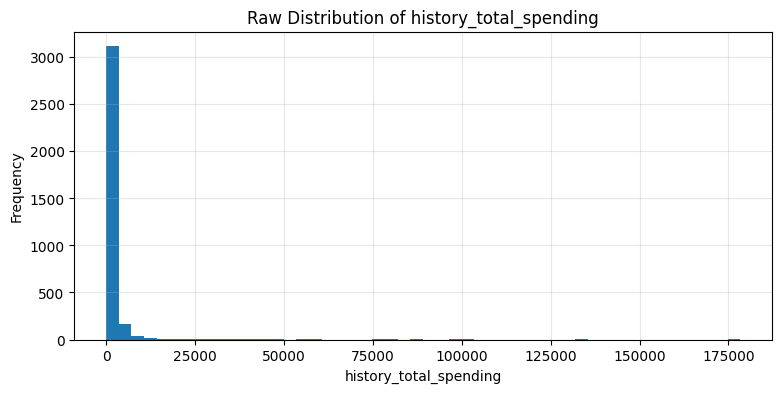

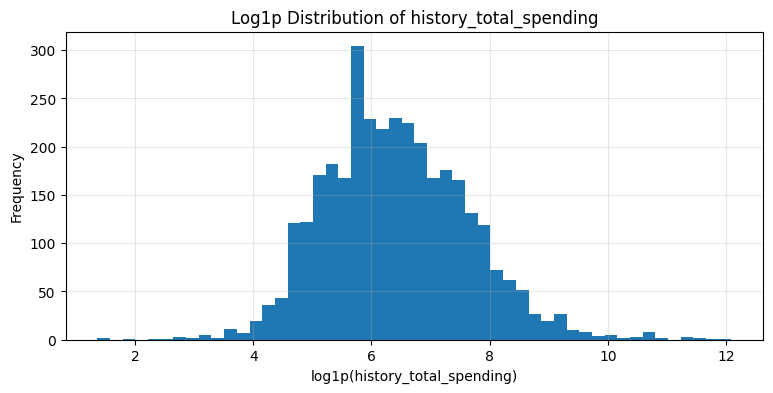

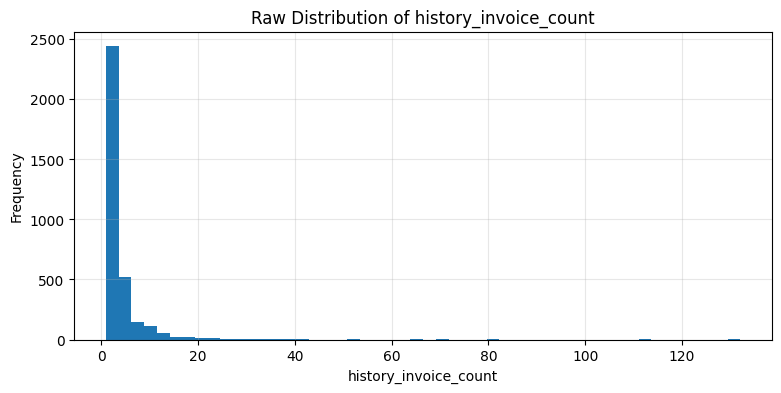

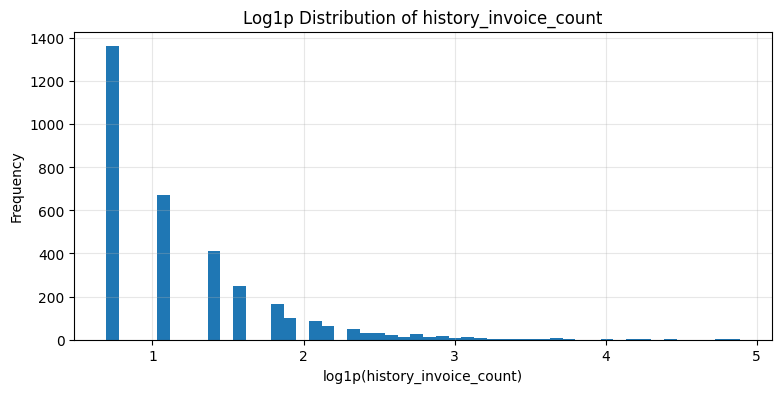

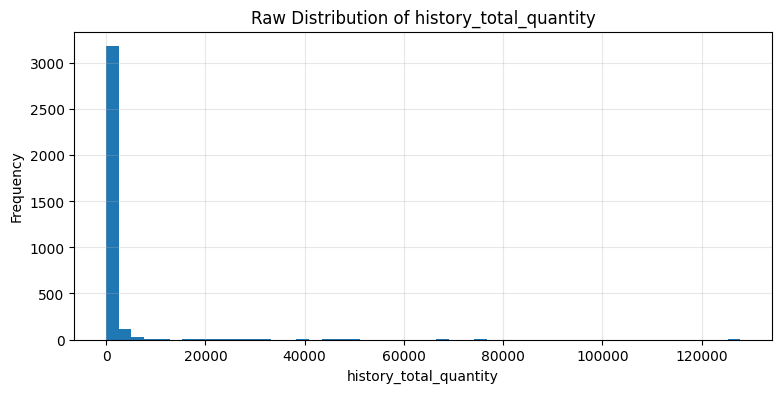

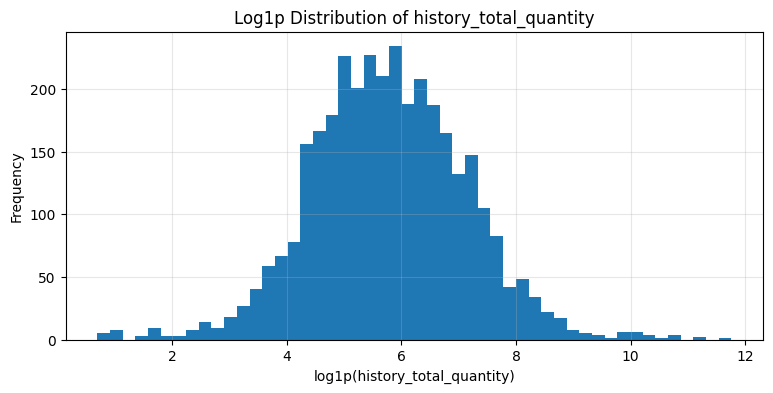

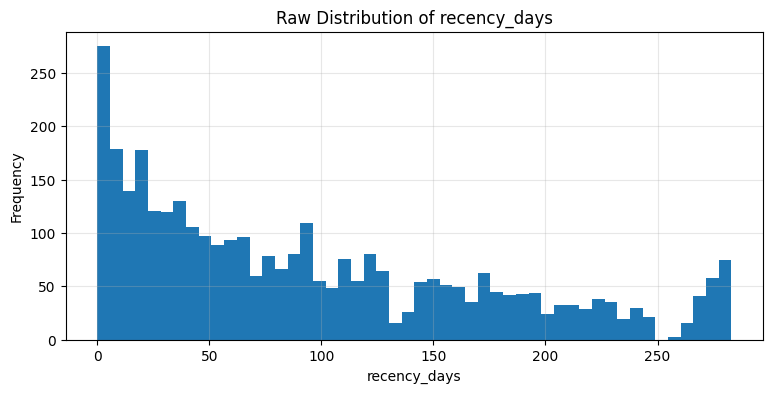

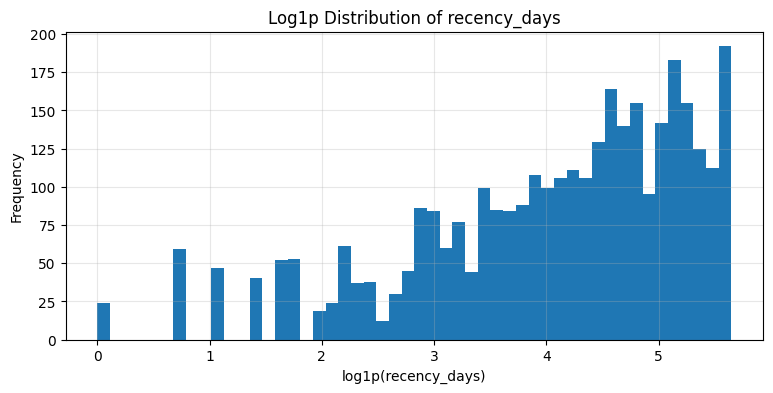

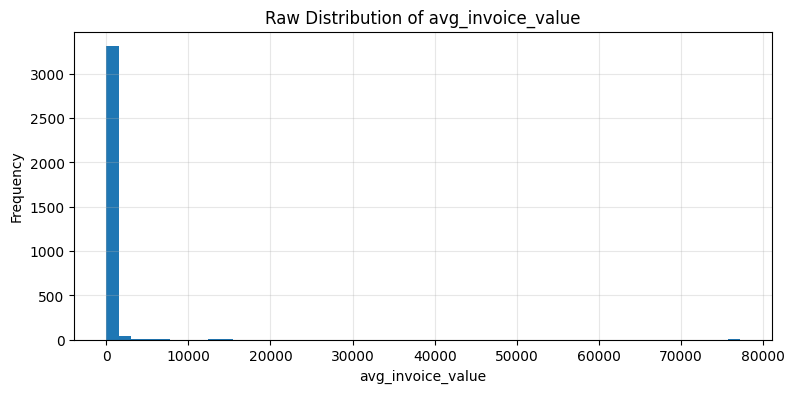

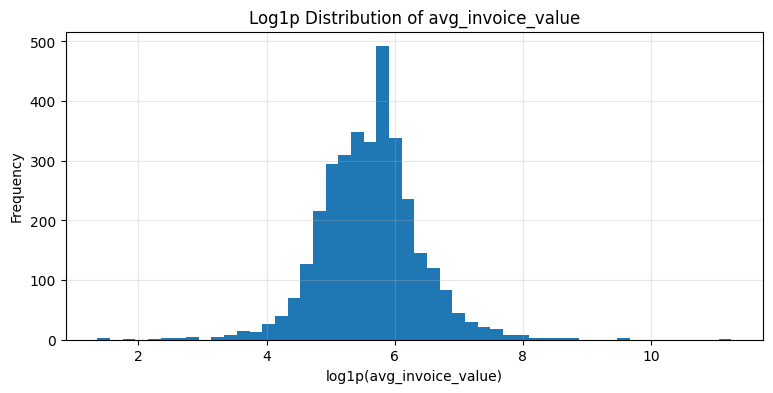

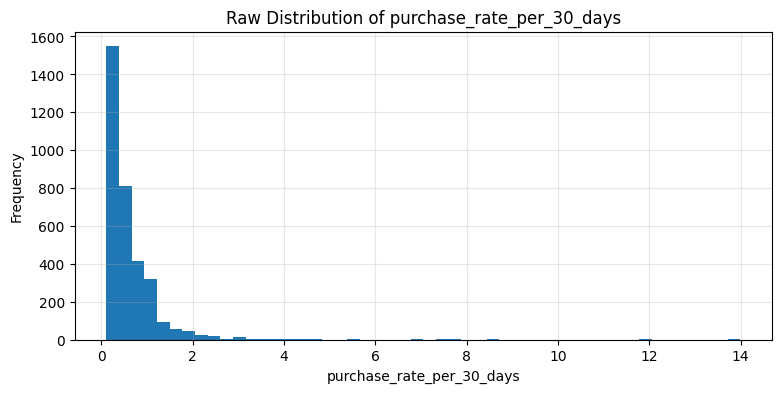

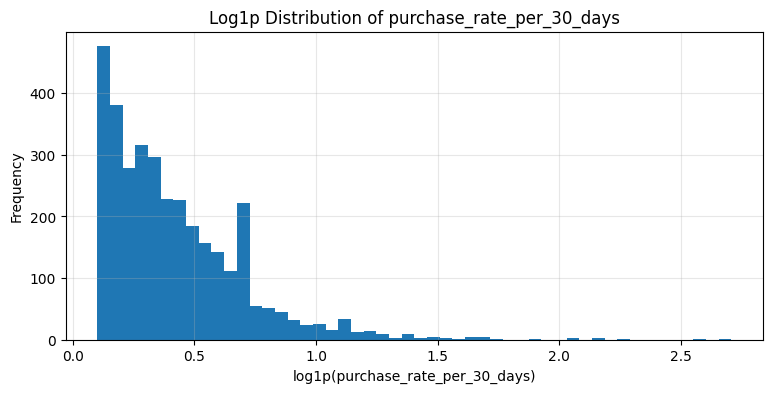

In [17]:
# ============================================================
# Section 16: Customer-Level Numeric Distribution Profile
# ============================================================

# Future columns are targets or target-derived quantities.
# They must not be used to build outlier scores, because this would leak future information
# into the historical input feature space.
future_leakage_columns = [
    "future_spending",
    "log1p_future_spending",
    "future_invoice_count",
    "future_line_count",
    "future_quantity",
    "future_unique_products",
    "future_active",
    "future_segment_id"
]

outlier_numeric_columns = [
    col for col in customer_model_df.columns
    if pd.api.types.is_numeric_dtype(customer_model_df[col])
    and col not in ["CustomerID"]
    and col not in future_leakage_columns
    and not col.startswith("future_")
]

outlier_column_leakage_audit = pd.DataFrame({
    "column": [col for col in customer_model_df.columns if col in future_leakage_columns or col.startswith("future_")],
    "reason_excluded_from_outlier_analysis": "future target or target-derived column"
})

print("Leakage-safe numeric columns used for outlier analysis:")
print(outlier_numeric_columns)
print("\nFuture columns excluded from outlier analysis:")
display(outlier_column_leakage_audit)

outlier_profile_rows = []
for col in outlier_numeric_columns:
    x = customer_model_df[col].dropna()
    if len(x) == 0:
        continue
    outlier_profile_rows.append({
        "column": col,
        "non_missing_count": len(x),
        "mean": x.mean(),
        "median": x.median(),
        "std": x.std(),
        "min": x.min(),
        "p01": x.quantile(0.01),
        "p25": x.quantile(0.25),
        "p75": x.quantile(0.75),
        "p99": x.quantile(0.99),
        "max": x.max(),
        "skewness": x.skew()
    })

customer_outlier_profile = pd.DataFrame(outlier_profile_rows).sort_values("skewness", ascending=False).reset_index(drop=True)
display(customer_outlier_profile)

important_plot_cols = [
    "history_total_spending", "history_invoice_count", "history_total_quantity",
    "recency_days", "avg_invoice_value", "purchase_rate_per_30_days"
]
important_plot_cols = [c for c in important_plot_cols if c in customer_model_df.columns]

for col in important_plot_cols:
    x = customer_model_df[col].dropna()
    plt.figure(figsize=(9, 4))
    plt.hist(x, bins=50)
    plt.title(f"Raw Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()
    if x.min() >= 0:
        plt.figure(figsize=(9, 4))
        plt.hist(np.log1p(x), bins=50)
        plt.title(f"Log1p Distribution of {col}")
        plt.xlabel(f"log1p({col})")
        plt.ylabel("Frequency")
        plt.grid(alpha=0.3)
        plt.show()

In [18]:
# ============================================================
# Section 17: Z-score and IQR Outlier Detection
# ============================================================

def detect_zscore_outliers(data, columns, threshold=3.0):
    flags = pd.DataFrame(index=data.index)
    rows = []
    for col in columns:
        x = pd.to_numeric(data[col], errors="coerce")
        mean = x.mean()
        std = x.std()
        if pd.isna(std) or std == 0:
            flags[f"z_outlier__{col}"] = False
            continue
        z = ((x - mean) / std).abs()
        flag = (z > threshold).fillna(False)
        flags[f"z_outlier__{col}"] = flag
        rows.append({
            "column": col,
            "method": "Z-score",
            "threshold": threshold,
            "outlier_count": int(flag.sum()),
            "outlier_rate": flag.mean()
        })
    flags["zscore_outlier_any"] = flags.any(axis=1)
    return flags, pd.DataFrame(rows)


def detect_iqr_outliers(data, columns, multiplier=1.5):
    flags = pd.DataFrame(index=data.index)
    rows = []
    for col in columns:
        x = pd.to_numeric(data[col], errors="coerce")
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            flags[f"iqr_outlier__{col}"] = False
            continue
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        flag = ((x < lower) | (x > upper)).fillna(False)
        flags[f"iqr_outlier__{col}"] = flag
        rows.append({
            "column": col,
            "method": "IQR",
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(flag.sum()),
            "outlier_rate": flag.mean()
        })
    flags["iqr_outlier_any"] = flags.any(axis=1)
    return flags, pd.DataFrame(rows)

zscore_flags, zscore_summary = detect_zscore_outliers(customer_model_df, outlier_numeric_columns)
iqr_flags, iqr_summary = detect_iqr_outliers(customer_model_df, outlier_numeric_columns)

zscore_summary = zscore_summary.sort_values("outlier_rate", ascending=False).reset_index(drop=True)
iqr_summary = iqr_summary.sort_values("outlier_rate", ascending=False).reset_index(drop=True)

display(zscore_summary.head(50))
display(iqr_summary.head(50))
print("Rows flagged by Z-score:", zscore_flags["zscore_outlier_any"].sum())
print("Rows flagged by IQR:", iqr_flags["iqr_outlier_any"].sum())

,column,method,threshold,outlier_count,outlier_rate
0,weekend_purchase_rate,Z-score,3.0,210,0.062315
1,after_hours_purchase_rate,Z-score,3.0,107,0.031751
2,product_diversity_per_invoice,Z-score,3.0,51,0.015134
3,avg_invoice_unique_products,Z-score,3.0,50,0.014837
4,avg_invoice_line_count,Z-score,3.0,49,0.014540
5,lines_per_invoice,Z-score,3.0,49,0.014540
6,history_unique_products,Z-score,3.0,47,0.013947
7,history_unique_descriptions,Z-score,3.0,47,0.013947
8,history_invoice_count,Z-score,3.0,44,0.013056
9,purchase_rate_per_30_days,Z-score,3.0,43,0.012760


,column,method,lower_bound,upper_bound,outlier_count,outlier_rate
0,history_avg_line_value,IQR,-6.451250,44.752083,390,0.115727
1,history_median_line_value,IQR,-3.697500,32.162500,372,0.110386
2,history_max_line_value,IQR,-75.843750,208.706250,357,0.105935
3,history_max_unit_price,IQR,-4.050000,27.950000,348,0.103264
4,history_total_quantity,IQR,-842.500000,1753.500000,321,0.095252
5,history_total_spending,IQR,-1421.806250,3075.383750,302,0.089614
6,history_line_count,IQR,-78.000000,170.000000,296,0.087834
7,history_invoice_count,IQR,-3.500000,8.500000,262,0.077745
8,max_invoice_value,IQR,-345.975000,1119.245000,262,0.077745
9,avg_invoice_value,IQR,-197.860250,778.573750,252,0.074777


Rows flagged by Z-score: 481
Rows flagged by IQR: 1579


In [19]:
# ============================================================
# Section 18: Simple Isolation Forest from Scratch with NumPy
# ============================================================

def average_path_length(n):
    n = np.asarray(n, dtype=float)
    result = np.zeros_like(n, dtype=float)
    mask_gt_2 = n > 2
    mask_eq_2 = n == 2
    result[mask_eq_2] = 1.0
    result[mask_gt_2] = 2.0 * (np.log(n[mask_gt_2] - 1.0) + 0.5772156649) - (2.0 * (n[mask_gt_2] - 1.0) / n[mask_gt_2])
    return result

class IsolationTreeNode:
    def __init__(self, size, depth, feature_index=None, split_value=None, left=None, right=None):
        self.size = size
        self.depth = depth
        self.feature_index = feature_index
        self.split_value = split_value
        self.left = left
        self.right = right
    @property
    def is_external(self):
        return self.left is None and self.right is None

class IsolationTree:
    def __init__(self, max_depth, random_state=None):
        self.max_depth = max_depth
        self.rng = np.random.default_rng(random_state)
        self.root = None
    def fit(self, X):
        self.root = self._build_tree(np.asarray(X, dtype=float), 0)
        return self
    def _build_tree(self, X, depth):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples <= 1:
            return IsolationTreeNode(n_samples, depth)
        mins = np.nanmin(X, axis=0)
        maxs = np.nanmax(X, axis=0)
        valid = np.where(maxs > mins)[0]
        if len(valid) == 0:
            return IsolationTreeNode(n_samples, depth)
        feature = int(self.rng.choice(valid))
        split = float(self.rng.uniform(mins[feature], maxs[feature]))
        left_mask = X[:, feature] < split
        right_mask = ~left_mask
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return IsolationTreeNode(n_samples, depth)
        return IsolationTreeNode(
            n_samples, depth, feature, split,
            self._build_tree(X[left_mask], depth + 1),
            self._build_tree(X[right_mask], depth + 1)
        )
    def path_length_one(self, x, node=None, depth=0):
        if node is None:
            node = self.root
        if node.is_external:
            return depth + float(average_path_length(np.array([node.size]))[0])
        if x[node.feature_index] < node.split_value:
            return self.path_length_one(x, node.left, depth + 1)
        return self.path_length_one(x, node.right, depth + 1)
    def path_length(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self.path_length_one(row) for row in X], dtype=float)

class SimpleIsolationForest:
    def __init__(self, n_trees=100, sample_size=256, max_depth=None, random_state=42):
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.max_depth = max_depth
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []
        self.actual_sample_size_ = None
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n = X.shape[0]
        self.actual_sample_size_ = min(self.sample_size, n)
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(self.actual_sample_size_)))
        self.trees = []
        for _ in range(self.n_trees):
            idx = self.rng.choice(n, size=self.actual_sample_size_, replace=False)
            tree = IsolationTree(self.max_depth, random_state=self.rng.integers(0, 10**9))
            tree.fit(X[idx])
            self.trees.append(tree)
        return self
    def path_length(self, X):
        X = np.asarray(X, dtype=float)
        paths = np.zeros((X.shape[0], len(self.trees)))
        for j, tree in enumerate(self.trees):
            paths[:, j] = tree.path_length(X)
        return paths.mean(axis=1)
    def anomaly_score(self, X):
        h = self.path_length(X)
        c = float(average_path_length(np.array([self.actual_sample_size_]))[0])
        if c == 0:
            return np.ones_like(h)
        return 2 ** (-h / c)
    def predict(self, X, contamination=0.05):
        scores = self.anomaly_score(X)
        threshold = np.quantile(scores, 1 - contamination)
        labels = (scores >= threshold).astype(int)
        return labels, scores, threshold


def prepare_iforest_matrix(data, columns, log_skew_threshold=1.0, clip_value=10.0):
    X_df = data[columns].copy()
    transform_rows = []
    for col in X_df.columns:
        x = pd.to_numeric(X_df[col], errors="coerce")
        skew = x.dropna().skew()
        min_value = x.min(skipna=True)
        log_applied = False
        if pd.notna(skew) and skew > log_skew_threshold and pd.notna(min_value) and min_value >= 0:
            x = np.log1p(x)
            log_applied = True
        median = x.median()
        x = x.fillna(median)
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            iqr = 1.0
        X_df[col] = ((x - median) / iqr).clip(-clip_value, clip_value)
        transform_rows.append({
            "column": col,
            "original_skewness": skew,
            "log1p_applied": log_applied,
            "median_after_log_if_any": median,
            "iqr_after_log_if_any": iqr
        })
    return X_df.values.astype(float), pd.DataFrame(transform_rows)

X_iso, isolation_transform_table = prepare_iforest_matrix(customer_model_df, outlier_numeric_columns)

start_time = time.time()
iforest = SimpleIsolationForest(n_trees=60, sample_size=256, random_state=RANDOM_STATE)
iforest.fit(X_iso)
iforest_labels, iforest_scores, iforest_threshold = iforest.predict(X_iso, contamination=0.05)
iforest_runtime = time.time() - start_time

customer_model_df["simple_iforest_score"] = iforest_scores
customer_model_df["simple_iforest_outlier"] = iforest_labels

print("Simple Isolation Forest finished.")
print(f"Runtime: {iforest_runtime:.4f} seconds")
print(f"Threshold: {iforest_threshold:.6f}")
print(f"Anomalies: {customer_model_df['simple_iforest_outlier'].sum()}")
display(isolation_transform_table.head(50))

Simple Isolation Forest finished.
Runtime: 4.1158 seconds
Threshold: 0.546252
Anomalies: 169


,column,original_skewness,log1p_applied,median_after_log_if_any,iqr_after_log_if_any
0,history_line_count,13.694156,True,3.526361,1.584120
1,history_invoice_count,9.256801,True,1.098612,0.916291
2,history_unique_products,6.206616,True,3.401197,1.450833
3,history_unique_descriptions,6.233584,True,3.401197,1.450833
4,history_total_quantity,18.073037,True,5.749393,1.777773
5,history_total_spending,16.126953,True,6.335426,1.654870
6,history_avg_line_value,55.200049,True,2.935233,0.658022
7,history_median_line_value,57.382825,True,2.821379,0.606474
8,history_max_line_value,43.909605,True,3.951244,1.173318
9,history_avg_unit_price,23.435375,True,1.390947,0.430027


In [20]:
# ============================================================
# Section 19: Compare Outlier Methods and Treat Outliers
# ============================================================

outlier_comparison = pd.DataFrame(index=customer_model_df.index)
outlier_comparison["zscore_outlier"] = zscore_flags["zscore_outlier_any"].astype(int)
outlier_comparison["iqr_outlier"] = iqr_flags["iqr_outlier_any"].astype(int)
outlier_comparison["simple_iforest_outlier"] = customer_model_df["simple_iforest_outlier"].astype(int)
outlier_comparison["number_of_methods_flagged"] = outlier_comparison.sum(axis=1)

method_summary = pd.DataFrame({
    "method": ["Z-score", "IQR", "Simple Isolation Forest"],
    "outlier_count": [
        outlier_comparison["zscore_outlier"].sum(),
        outlier_comparison["iqr_outlier"].sum(),
        outlier_comparison["simple_iforest_outlier"].sum()
    ],
    "outlier_rate": [
        outlier_comparison["zscore_outlier"].mean(),
        outlier_comparison["iqr_outlier"].mean(),
        outlier_comparison["simple_iforest_outlier"].mean()
    ]
})

customer_model_df["zscore_outlier_any"] = outlier_comparison["zscore_outlier"]
customer_model_df["iqr_outlier_any"] = outlier_comparison["iqr_outlier"]
customer_model_df["number_of_outlier_methods_flagged"] = outlier_comparison["number_of_methods_flagged"]
customer_model_df["high_confidence_outlier"] = (
    (customer_model_df["simple_iforest_outlier"] == 1)
    & ((customer_model_df["zscore_outlier_any"] == 1) | (customer_model_df["iqr_outlier_any"] == 1))
).astype(int)

# These outlier fields are analysis-only. They are useful for data-quality discussion
# and failure analysis, but they are removed from the model input feature list to avoid
# pre-split preprocessing leakage.
global_outlier_analysis_features = [
    "simple_iforest_score",
    "simple_iforest_outlier",
    "zscore_outlier_any",
    "iqr_outlier_any",
    "number_of_outlier_methods_flagged",
    "high_confidence_outlier"
]

outlier_feature_usage_table = pd.DataFrame({
    "feature": global_outlier_analysis_features,
    "usage": "analysis_only_not_model_input",
    "reason": "created before train/test split; kept for data quality and failure analysis only"
})

display(outlier_feature_usage_table)

# Only historical feature columns are winsorized for feature engineering.
# The regression target `future_spending` is not winsorized as an input feature.
winsorize_columns = [
    "history_total_spending", "history_invoice_count", "history_total_quantity",
    "avg_invoice_value", "purchase_rate_per_30_days"
]
winsorize_columns = [c for c in winsorize_columns if c in customer_model_df.columns]

winsorization_rows = []
for col in winsorize_columns:
    lower = customer_model_df[col].quantile(0.01)
    upper = customer_model_df[col].quantile(0.99)
    new_col = f"{col}_winsorized_p01_p99"
    customer_model_df[new_col] = customer_model_df[col].clip(lower, upper)
    winsorization_rows.append({
        "column": col,
        "winsorized_column": new_col,
        "lower_cap_p01": lower,
        "upper_cap_p99": upper,
        "values_below_lower_cap": int((customer_model_df[col] < lower).sum()),
        "values_above_upper_cap": int((customer_model_df[col] > upper).sum())
    })

winsorization_table = pd.DataFrame(winsorization_rows)

display(method_summary)
display(outlier_comparison["number_of_methods_flagged"].value_counts().sort_index())
display(winsorization_table)

display(customer_model_df.sort_values(["number_of_outlier_methods_flagged", "simple_iforest_score"], ascending=[False, False]).head(20))

,feature,usage,reason
0,simple_iforest_score,analysis_only_not_model_input,created before train/test split; kept for data...
1,simple_iforest_outlier,analysis_only_not_model_input,created before train/test split; kept for data...
2,zscore_outlier_any,analysis_only_not_model_input,created before train/test split; kept for data...
3,iqr_outlier_any,analysis_only_not_model_input,created before train/test split; kept for data...
4,number_of_outlier_methods_flagged,analysis_only_not_model_input,created before train/test split; kept for data...
5,high_confidence_outlier,analysis_only_not_model_input,created before train/test split; kept for data...


,method,outlier_count,outlier_rate
0,Z-score,481,0.142730
1,IQR,1579,0.468546
2,Simple Isolation Forest,169,0.050148


number_of_methods_flagged
0    1594
1    1392
2     315
3      69
Name: count, dtype: int64

,column,winsorized_column,lower_cap_p01,upper_cap_p99,values_below_lower_cap,values_above_upper_cap
0,history_total_spending,history_total_spending_winsorized_p01_p99,48.910400,14538.151400,34,34
1,history_invoice_count,history_invoice_count_winsorized_p01_p99,1.000000,23.000000,0,32
2,history_total_quantity,history_total_quantity_winsorized_p01_p99,9.690000,8926.360000,34,34
3,avg_invoice_value,avg_invoice_value_winsorized_p01_p99,38.803800,2032.978100,34,34
4,purchase_rate_per_30_days,purchase_rate_per_30_days_winsorized_p01_p99,0.106762,2.964586,33,34


,CustomerID,first_purchase_date,last_purchase_date,history_line_count,history_invoice_count,history_unique_products,history_unique_descriptions,history_total_quantity,history_total_spending,history_avg_line_value,history_median_line_value,history_max_line_value,history_avg_unit_price,history_median_unit_price,history_max_unit_price,weekend_purchase_rate,after_hours_purchase_rate,avg_month_sin,avg_month_cos,avg_dayofweek_sin,avg_dayofweek_cos,dominant_country,avg_invoice_value,median_invoice_value,max_invoice_value,avg_invoice_quantity,avg_invoice_unique_products,avg_invoice_line_count,recency_days,customer_age_days,active_span_days,purchase_rate_per_30_days,monetary_per_invoice,quantity_per_invoice,product_diversity_per_invoice,lines_per_invoice,R_score,F_score,M_score,RFM_score,historical_rfm_segment,future_spending,future_invoice_count,future_line_count,future_quantity,future_unique_products,log1p_future_spending,future_active,future_customer_segment,future_segment_id,simple_iforest_score,simple_iforest_outlier,zscore_outlier_any,iqr_outlier_any,number_of_outlier_methods_flagged,high_confidence_outlier,history_total_spending_winsorized_p01_p99,history_invoice_count_winsorized_p01_p99,history_total_quantity_winsorized_p01_p99,avg_invoice_value_winsorized_p01_p99,purchase_rate_per_30_days_winsorized_p01_p99
1595,15098,2011-06-10 15:22:00,2011-06-10 15:33:00,3,3,1,2,121,39916.50,13305.500000,649.50,38970.00,434.650000,649.50,649.50,0.000000,0.000000,1.224647e-16,-1.000000e+00,-0.433884,-0.900969,United Kingdom,13305.500000,649.50,38970.00,40.333333,1.000000,1.000000,91,91,0,0.989011,13305.500000,40.333333,0.333333,1.000000,3,4,5,12,Historical Big Spenders,0.00,0.0,0.0,0.0,0.0,0.000000,0,Future Inactive,0,0.678280,1,1,1,3,1,14538.1514,3,121.00,2032.978100,0.989011
3256,18087,2011-02-22 10:43:00,2011-09-02 15:12:00,2,2,2,2,3907,4055.72,2027.860000,2027.86,3202.92,426.810000,426.81,852.80,0.000000,0.000000,-6.698730e-02,2.500000e-01,0.173974,-0.138740,United Kingdom,2027.860000,2027.86,3202.92,1953.500000,1.000000,1.000000,7,200,192,0.300000,2027.860000,1953.500000,1.000000,1.000000,5,3,5,13,Historical Big Spenders,0.00,0.0,0.0,0.0,0.0,0.000000,0,Future Inactive,0,0.676399,1,1,1,3,1,4055.7200,2,3907.00,2027.860000,0.300000
1992,15802,2011-07-20 11:38:00,2011-07-20 11:38:00,1,1,1,1,1,451.42,451.420000,451.42,451.42,451.420000,451.42,451.42,0.000000,0.000000,-5.000000e-01,-8.660254e-01,0.974928,-0.222521,United Kingdom,451.420000,451.42,451.42,1.000000,1.000000,1.000000,52,52,0,0.576923,451.420000,1.000000,1.000000,1.000000,3,2,3,8,Historical Regular,0.00,0.0,0.0,0.0,0.0,0.000000,0,Future Inactive,0,0.660952,1,1,1,3,1,451.4200,1,9.69,451.420000,0.576923
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,1,1,1,74215,77183.60,77183.600000,77183.60,77183.60,1.040000,1.04,1.04,0.000000,0.000000,5.000000e-01,8.660254e-01,0.781831,0.623490,United Kingdom,77183.600000,77183.60,77183.60,74215.000000,1.000000,1.000000,235,235,0,0.127660,77183.600000,74215.000000,1.000000,1.000000,1,1,5,7,Historical Big Spenders,0.00,0.0,0.0,0.0,0.0,0.000000,0,Future Inactive,0,0.654041,1,1,1,3,1,14538.1514,1,8926.36,2032.978100,0.127660
3341,18233,2011-01-18 08:44:00,2011-01-18 08:44:00,1,1,1,1,4,440.00,440.000000,440.00,440.00,110.000000,110.00,110.00,0.000000,1.000000,5.000000e-01,8.660254e-01,0.781831,0.623490,United Kingdom,440.000000,440.00,440.00,4.000000,1.000000,1.000000,235,235,0,0.127660,440.000000,4.000000,1.000000,1.000000,1,2,3,6,Historical Regular,0.00,0.0,0.0,0.0,0.0,0.000000,0,Future Inactive,0,0.652832,1,1,1,3,1,440.0000,1,9.69,440.000000,0.127660
46,12415,2011-01-06 11:12:00,2011-09-01 13:51:00,600,15,382,387,66701,102087.88,170.146467,129.75,1260.00,2.946500,1.45,350.00,0.000000,0.161667,1.185289e-01,-4.131613e-01,0.688860,-0.209008,Australia,6805.858667,2732.92,22775.93,4446.733333,40.000000,40.000000,8,247,238,1.821862,6805.858667,4446.733333,25.466667,40.000000,5,5,5,15,Historical Champions,22826.65,6.0,114.0,10673.0,106.0,10.035728,1,Fu

## 20. Feature Quality Analysis

Before modeling, we identify feature-quality problems:

- Direct target leakage
- Future-derived variables
- Identifier columns
- Near-constant features
- High-cardinality categorical features
- Redundant numerical variables

For this dataset, leakage is especially important because future targets are created from future transactions. No `future_*` variable should be used as an input feature.

In [21]:
# ============================================================
# Section 20: Feature Quality Analysis
# ============================================================

feature_quality_rows = []

leakage_keywords = ["future_", "log1p_future_spending", "future_customer_segment", "future_segment_id"]
identifier_columns = ["CustomerID"]
raw_date_columns = ["first_purchase_date", "last_purchase_date"]
global_outlier_analysis_features = [
    "simple_iforest_score",
    "simple_iforest_outlier",
    "zscore_outlier_any",
    "iqr_outlier_any",
    "number_of_outlier_methods_flagged",
    "high_confidence_outlier"
]

for col in customer_model_df.columns:
    dtype = str(customer_model_df[col].dtype)
    missing_rate = customer_model_df[col].isna().mean()
    unique_count = customer_model_df[col].nunique(dropna=False)
    unique_rate = unique_count / len(customer_model_df)
    dominant_rate = customer_model_df[col].value_counts(dropna=False, normalize=True).iloc[0]

    if col in identifier_columns:
        quality_flag = "identifier"
        recommendation = "drop_identifier"
    elif col in raw_date_columns:
        quality_flag = "raw_date"
        recommendation = "drop_raw_date_keep_engineered_days"
    elif any(key in col for key in leakage_keywords):
        quality_flag = "target_or_future_leakage"
        recommendation = "drop_from_features_leakage"
    elif col in global_outlier_analysis_features:
        quality_flag = "analysis_only_pre_split_outlier_feature"
        recommendation = "drop_analysis_only_pre_split_feature"
    elif unique_count == 1 or dominant_rate >= 0.99:
        quality_flag = "near_constant_or_constant"
        recommendation = "drop_near_constant"
    elif customer_model_df[col].dtype == "object" and unique_count > 50:
        quality_flag = "high_cardinality_categorical"
        recommendation = "review_or_encode_carefully"
    else:
        quality_flag = "usable_candidate"
        recommendation = "keep_candidate"

    feature_quality_rows.append({
        "column": col,
        "dtype": dtype,
        "missing_rate": missing_rate,
        "unique_count": unique_count,
        "unique_rate": unique_rate,
        "dominant_rate": dominant_rate,
        "quality_flag": quality_flag,
        "recommendation": recommendation
    })

feature_quality_table = pd.DataFrame(feature_quality_rows).sort_values(["recommendation", "missing_rate"], ascending=[True, False]).reset_index(drop=True)

display(feature_quality_table)

numeric_candidate_cols = [
    col for col in customer_model_df.columns
    if pd.api.types.is_numeric_dtype(customer_model_df[col])
    and col not in identifier_columns
    and col not in global_outlier_analysis_features
    and not any(key in col for key in leakage_keywords)
    and customer_model_df[col].nunique(dropna=True) > 1
]

corr_matrix = customer_model_df[numeric_candidate_cols].corr(method="spearman").abs()
redundant_pairs = []
for i, c1 in enumerate(corr_matrix.columns):
    for j, c2 in enumerate(corr_matrix.columns):
        if j <= i:
            continue
        val = corr_matrix.loc[c1, c2]
        if pd.notna(val) and val >= 0.90:
            redundant_pairs.append({"feature_1": c1, "feature_2": c2, "abs_spearman_corr": val})
redundant_pairs_table = pd.DataFrame(redundant_pairs).sort_values("abs_spearman_corr", ascending=False).reset_index(drop=True) if redundant_pairs else pd.DataFrame(columns=["feature_1","feature_2","abs_spearman_corr"])

display(redundant_pairs_table.head(80))

,column,dtype,missing_rate,unique_count,unique_rate,dominant_rate,quality_flag,recommendation
0,simple_iforest_score,float64,0.0,3370,1.000000,0.000297,analysis_only_pre_split_outlier_feature,drop_analysis_only_pre_split_feature
1,simple_iforest_outlier,int64,0.0,2,0.000593,0.949852,analysis_only_pre_split_outlier_feature,drop_analysis_only_pre_split_feature
2,zscore_outlier_any,int64,0.0,2,0.000593,0.857270,analysis_only_pre_split_outlier_feature,drop_analysis_only_pre_split_feature
3,iqr_outlier_any,int64,0.0,2,0.000593,0.531454,analysis_only_pre_split_outlier_feature,drop_analysis_only_pre_split_feature
4,number_of_outlier_methods_flagged,int64,0.0,4,0.001187,0.472997,analysis_only_pre_split_outlier_feature,drop_analysis_only_pre_split_feature
5,high_confidence_outlier,int64,0.0,2,0.000593,0.952819,analysis_only_pre_split_outlier_feature,drop_analysis_only_pre_split_feature
6,future_spending,float64,0.0,1911,0.567062,0.429970,target_or_future_leakage,drop_from_features_leakage
7,future_invoice_count,float64,0.0,27,0.008012,0.429970,target_or_future_leakage,drop_from_features_leakage
8,future_line_count,float64,0.0,245,0.072700,0.429970,target_or_future_leakage,drop_from_features_leakage
9,future_quantity,float64,0.0,969,0.287537,0.429970,target_or_future_leakage,drop_from_features_leakage


,feature_1,feature_2,abs_spearman_corr
0,avg_invoice_line_count,lines_per_invoice,1.000000
1,avg_invoice_quantity,quantity_per_invoice,1.000000
2,avg_invoice_value,monetary_per_invoice,1.000000
3,history_invoice_count,history_invoice_count_winsorized_p01_p99,0.999999
4,history_total_quantity,history_total_quantity_winsorized_p01_p99,0.999999
5,avg_invoice_value,avg_invoice_value_winsorized_p01_p99,0.999999
6,monetary_per_invoice,avg_invoice_value_winsorized_p01_p99,0.999999
7,history_total_spending,history_total_spending_winsorized_p01_p99,0.999999
8,purchase_rate_per_30_days,purchase_rate_per_30_days_winsorized_p01_p99,0.999998
9,history_unique_products,history_unique_descriptions,0.999924


## 21. Final Feature Lists for Modeling

We build one feature list that can be used for both tasks.

Dropped fields include:

- `CustomerID`
- future targets
- future-derived columns
- raw date columns
- near-constant columns

The customer-level input features are historical behavioral variables only.

In [22]:
# ============================================================
# Section 21: Final Feature Lists for Modeling
# ============================================================

feature_candidates = feature_quality_table.loc[
    feature_quality_table["recommendation"].isin(["keep_candidate", "review_or_encode_carefully"]),
    "column"
].tolist()

future_or_target_leakage_candidates = [
    "CustomerID",
    "future_spending",
    "log1p_future_spending",
    "future_customer_segment",
    "future_segment_id",
    "future_invoice_count",
    "future_line_count",
    "future_quantity",
    "future_unique_products",
    "future_active"
]

global_outlier_feature_leakage_candidates = [
    "simple_iforest_score",
    "simple_iforest_outlier",
    "zscore_outlier_any",
    "iqr_outlier_any",
    "number_of_outlier_methods_flagged",
    "high_confidence_outlier"
]

raw_non_model_columns = [
    "first_purchase_date",
    "last_purchase_date"
]

removed_from_modeling_due_to_leakage = []
clean_features = []

for col in feature_candidates:
    remove_reason = None
    if col in future_or_target_leakage_candidates or col.startswith("future_"):
        remove_reason = "future target or target-derived leakage"
    elif col in global_outlier_feature_leakage_candidates:
        remove_reason = "pre-split global outlier analysis feature"
    elif col in raw_non_model_columns:
        remove_reason = "raw date column replaced by engineered day-difference features"

    if remove_reason is None:
        clean_features.append(col)
    else:
        removed_from_modeling_due_to_leakage.append({
            "column": col,
            "reason_removed": remove_reason
        })

feature_candidates = list(dict.fromkeys(clean_features))
leakage_safety_audit_table = pd.DataFrame(removed_from_modeling_due_to_leakage)

# Final hard assertions to guarantee leakage-safe feature construction.
for col in feature_candidates:
    assert col not in future_or_target_leakage_candidates, f"Leakage column remained in features: {col}"
    assert not col.startswith("future_"), f"Future-derived column remained in features: {col}"
    assert col not in global_outlier_feature_leakage_candidates, f"Global outlier feature remained in features: {col}"
    assert col not in raw_non_model_columns, f"Raw non-model column remained in features: {col}"

print("Number of final candidate features after leakage-safe filtering:", len(feature_candidates))
print(feature_candidates)

print("\nColumns removed from modeling due to leakage or analysis-only status:")
display(leakage_safety_audit_table)

modeling_summary = pd.DataFrame({
    "item": ["customers", "features", "regression_target", "classification_target"],
    "value": [len(customer_model_df), len(feature_candidates), "log1p_future_spending", "future_segment_id"]
})
display(modeling_summary)

Number of final candidate features after leakage-safe filtering: 43
['history_line_count', 'history_invoice_count', 'history_unique_products', 'history_unique_descriptions', 'history_total_quantity', 'history_total_spending', 'history_avg_line_value', 'history_median_line_value', 'history_max_line_value', 'history_avg_unit_price', 'history_median_unit_price', 'history_max_unit_price', 'weekend_purchase_rate', 'after_hours_purchase_rate', 'avg_month_sin', 'avg_month_cos', 'avg_dayofweek_sin', 'avg_dayofweek_cos', 'dominant_country', 'avg_invoice_value', 'median_invoice_value', 'max_invoice_value', 'avg_invoice_quantity', 'avg_invoice_unique_products', 'avg_invoice_line_count', 'recency_days', 'customer_age_days', 'active_span_days', 'purchase_rate_per_30_days', 'monetary_per_invoice', 'quantity_per_invoice', 'product_diversity_per_invoice', 'lines_per_invoice', 'R_score', 'F_score', 'M_score', 'RFM_score', 'historical_rfm_segment', 'history_total_spending_winsorized_p01_p99', 'history_i

""


,item,value
0,customers,3370
1,features,43
2,regression_target,log1p_future_spending
3,classification_target,future_segment_id


## 22. From-Scratch Train/Test Split and Preprocessing

The models require numerical matrices.

We implement from scratch:

- Stratified train/test split for the classification target
- Median imputation and robust scaling for numerical features
- Unknown filling and top-k one-hot encoding for categorical features

All preprocessing parameters are fitted on the training data only.

In [23]:
# ============================================================
# Section 22: Train/Test Split and Preprocessing from Scratch
# ============================================================

class FromScratchTabularPreprocessor:
    def __init__(self, max_categories_per_feature=20, clip_value=10.0):
        self.max_categories_per_feature = max_categories_per_feature
        self.clip_value = clip_value
        self.numeric_columns_ = []
        self.categorical_columns_ = []
        self.numeric_medians_ = {}
        self.numeric_iqrs_ = {}
        self.categorical_levels_ = {}
        self.feature_names_ = []
    def fit(self, X_df):
        X_df = X_df.copy()
        self.numeric_columns_ = [c for c in X_df.columns if pd.api.types.is_numeric_dtype(X_df[c]) and X_df[c].nunique(dropna=True) > 1]
        self.categorical_columns_ = [c for c in X_df.columns if c not in self.numeric_columns_]
        for col in self.numeric_columns_:
            x = pd.to_numeric(X_df[col], errors="coerce")
            median = x.median()
            q1, q3 = x.quantile(0.25), x.quantile(0.75)
            iqr = q3 - q1
            if pd.isna(median): median = 0.0
            if pd.isna(iqr) or iqr == 0: iqr = 1.0
            self.numeric_medians_[col] = float(median)
            self.numeric_iqrs_[col] = float(iqr)
        for col in self.categorical_columns_:
            s = X_df[col].fillna("Unknown").astype(str).replace({"nan": "Unknown", "None": "Unknown"})
            levels = s.value_counts().head(self.max_categories_per_feature).index.tolist()
            if "Other" not in levels:
                levels.append("Other")
            self.categorical_levels_[col] = levels
        names = []
        names.extend(self.numeric_columns_)
        for col in self.categorical_columns_:
            names.extend([f"{col}__{level}" for level in self.categorical_levels_[col]])
        self.feature_names_ = names
        return self
    def transform(self, X_df):
        X_df = X_df.copy()
        matrices = []
        if self.numeric_columns_:
            X_num = np.zeros((len(X_df), len(self.numeric_columns_)), dtype=float)
            for j, col in enumerate(self.numeric_columns_):
                x = pd.to_numeric(X_df[col], errors="coerce").fillna(self.numeric_medians_[col])
                x = ((x - self.numeric_medians_[col]) / self.numeric_iqrs_[col]).clip(-self.clip_value, self.clip_value)
                X_num[:, j] = x.values.astype(float)
            matrices.append(X_num)
        cat_mats = []
        for col in self.categorical_columns_:
            s = X_df[col].fillna("Unknown").astype(str).replace({"nan": "Unknown", "None": "Unknown"})
            levels = self.categorical_levels_[col]
            level_to_idx = {v: i for i, v in enumerate(levels)}
            s = s.where(s.isin(levels), "Other")
            X_cat = np.zeros((len(X_df), len(levels)), dtype=float)
            for i, v in enumerate(s.values):
                X_cat[i, level_to_idx.get(v, level_to_idx["Other"])] = 1.0
            cat_mats.append(X_cat)
        if cat_mats:
            matrices.append(np.hstack(cat_mats))
        return np.hstack(matrices) if matrices else np.empty((len(X_df), 0))
    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)


def stratified_split_indices(y, test_size=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n_test = int(np.ceil(test_size * len(idx)))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    train_idx = np.array(train_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)
    rng.shuffle(train_idx); rng.shuffle(test_idx)
    return train_idx, test_idx

X_df = customer_model_df[feature_candidates].copy()
y_reg_raw = customer_model_df["future_spending"].values.astype(float)
y_reg_log = customer_model_df["log1p_future_spending"].values.astype(float)
y_cls = customer_model_df["future_segment_id"].values.astype(int)

train_idx, test_idx = stratified_split_indices(y_cls, test_size=0.25, random_state=RANDOM_STATE)

X_train_df = X_df.iloc[train_idx].copy()
X_test_df = X_df.iloc[test_idx].copy()

y_train_reg_raw = y_reg_raw[train_idx]
y_test_reg_raw = y_reg_raw[test_idx]
y_train_reg_log = y_reg_log[train_idx]
y_test_reg_log = y_reg_log[test_idx]
y_train_cls = y_cls[train_idx]
y_test_cls = y_cls[test_idx]

preprocessor = FromScratchTabularPreprocessor(max_categories_per_feature=25, clip_value=10.0)
X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train_reg_log:", y_train_reg_log.shape)
print("y_train_cls:", y_train_cls.shape)
print("Class distribution train:")
display(pd.Series(y_train_cls).map(id_to_segment).value_counts(normalize=True))
print("Class distribution test:")
display(pd.Series(y_test_cls).map(id_to_segment).value_counts(normalize=True))

sanity_check_table = pd.DataFrame({
    "dataset": ["X_train", "X_test"],
    "rows": [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
    "has_nan": [np.isnan(X_train).any(), np.isnan(X_test).any()],
    "has_inf": [np.isinf(X_train).any(), np.isinf(X_test).any()]
})
display(sanity_check_table)

X_train: (2526, 73)
X_test: (844, 73)
y_train_reg_log: (2526,)
y_train_cls: (2526,)
Class distribution train:


Future Inactive        0.429929
Future Medium Value    0.190024
Future Low Value       0.190024
Future High Value      0.190024
Name: proportion, dtype: float64

Class distribution test:


Future Inactive        0.430095
Future Medium Value    0.190758
Future Low Value       0.189573
Future High Value      0.189573
Name: proportion, dtype: float64

,dataset,rows,features,has_nan,has_inf
0,X_train,2526,73,False,False
1,X_test,844,73,False,False


## 23. Evaluation Metrics from Scratch

We implement all metrics manually using NumPy.

Regression metrics:

- MAE
- MSE
- RMSE
- R²
- MAPE

Classification metrics:

- Accuracy
- Macro precision
- Macro recall
- Macro F1
- Confusion matrix

In [24]:
# ============================================================
# Section 23: Evaluation Metrics from Scratch
# ============================================================

def regression_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100
    return {"model": label, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "MAPE": mape}


def confusion_matrix_from_scratch(y_true, y_pred, n_classes=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    if n_classes is None:
        n_classes = int(max(y_true.max(), y_pred.max())) + 1
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def classification_metrics(y_true, y_pred, label="model", n_classes=None):
    cm = confusion_matrix_from_scratch(y_true, y_pred, n_classes=n_classes)
    accuracy = np.trace(cm) / np.sum(cm) if np.sum(cm) else 0
    precisions, recalls, f1s = [], [], []
    for k in range(cm.shape[0]):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        precisions.append(precision); recalls.append(recall); f1s.append(f1)
    return {
        "model": label,
        "accuracy": accuracy,
        "macro_precision": float(np.mean(precisions)),
        "macro_recall": float(np.mean(recalls)),
        "macro_f1": float(np.mean(f1s))
    }

print("Metric functions defined successfully.")

Metric functions defined successfully.


## 24. Non-Kernel Models from Scratch

We implement:

- Linear Regression for future spending regression
- Multiclass Logistic Regression for customer segment classification
- KNN for regression and classification
- Decision Tree for regression and classification

All core model logic is implemented with NumPy.

In [25]:
# ============================================================
# Section 24: Non-Kernel Models from Scratch
# ============================================================

class LinearRegressionGD:
    def __init__(self, lr=0.05, n_iter=1500, l2=1e-4):
        self.lr = lr; self.n_iter = n_iter; self.l2 = l2; self.w = None; self.loss_history_ = []
    def fit(self, X, y):
        Xb = np.c_[np.ones(X.shape[0]), X]
        y = y.reshape(-1, 1)
        self.w = np.zeros((Xb.shape[1], 1))
        for _ in range(self.n_iter):
            pred = Xb @ self.w
            err = pred - y
            grad = (Xb.T @ err) / len(y)
            grad[1:] += self.l2 * self.w[1:]
            self.w -= self.lr * grad
            self.loss_history_.append(float(np.mean(err ** 2)))
        return self
    def predict(self, X):
        return (np.c_[np.ones(X.shape[0]), X] @ self.w).ravel()

class MulticlassLogisticRegressionGD:
    def __init__(self, lr=0.05, n_iter=1500, l2=1e-4):
        self.lr = lr; self.n_iter = n_iter; self.l2 = l2; self.W = None; self.classes_ = None; self.loss_history_ = []
    def _softmax(self, Z):
        Z = Z - np.max(Z, axis=1, keepdims=True)
        expZ = np.exp(Z)
        return expZ / np.sum(expZ, axis=1, keepdims=True)
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        y_idx = np.array([np.where(self.classes_ == v)[0][0] for v in y])
        Y = np.eye(n_classes)[y_idx]
        Xb = np.c_[np.ones(X.shape[0]), X]
        self.W = np.zeros((Xb.shape[1], n_classes))
        for _ in range(self.n_iter):
            P = self._softmax(Xb @ self.W)
            grad = (Xb.T @ (P - Y)) / Xb.shape[0]
            grad[1:] += self.l2 * self.W[1:]
            self.W -= self.lr * grad
            loss = -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))
            self.loss_history_.append(float(loss))
        return self
    def predict_proba(self, X):
        return self._softmax(np.c_[np.ones(X.shape[0]), X] @ self.W)
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

class KNNFromScratch:
    def __init__(self, k=7, task="classification"):
        self.k = k; self.task = task
    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float); self.y_train = np.asarray(y)
        return self
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = []
        for row in X:
            d = np.sqrt(np.sum((self.X_train - row) ** 2, axis=1))
            idx = np.argsort(d)[:self.k]
            vals = self.y_train[idx]
            if self.task == "regression":
                preds.append(np.mean(vals))
            else:
                preds.append(Counter(vals).most_common(1)[0][0])
        return np.array(preds)

class SimpleDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=20, task="classification", max_features=25, random_state=42):
        self.max_depth=max_depth; self.min_samples_split=min_samples_split; self.task=task; self.max_features=max_features; self.rng=np.random.default_rng(random_state)
    def fit(self, X, y):
        self.X = np.asarray(X, dtype=float); self.y = np.asarray(y)
        self.n_classes_ = len(np.unique(y)) if self.task == "classification" else None
        self.root = self._build(self.X, self.y, 0)
        return self
    def _leaf_value(self, y):
        if self.task == "regression": return float(np.mean(y))
        return Counter(y).most_common(1)[0][0]
    def _impurity(self, y):
        if self.task == "regression": return np.var(y)
        counts = np.array(list(Counter(y).values()), dtype=float)
        p = counts / counts.sum()
        return 1 - np.sum(p ** 2)
    def _best_split(self, X, y):
        n, p = X.shape
        feature_indices = np.arange(p)
        if self.max_features is not None and p > self.max_features:
            feature_indices = self.rng.choice(feature_indices, size=self.max_features, replace=False)
        best = {"gain": 0, "feature": None, "threshold": None}
        parent_impurity = self._impurity(y)
        for j in feature_indices:
            vals = X[:, j]
            unique_vals = np.unique(vals)
            if len(unique_vals) <= 1: continue
            thresholds = np.quantile(unique_vals, np.linspace(0.1, 0.9, 9))
            for thr in thresholds:
                left = vals <= thr; right = ~left
                if left.sum() < self.min_samples_split or right.sum() < self.min_samples_split: continue
                child_impurity = (left.mean() * self._impurity(y[left])) + (right.mean() * self._impurity(y[right]))
                gain = parent_impurity - child_impurity
                if gain > best["gain"]:
                    best = {"gain": gain, "feature": j, "threshold": thr}
        return best
    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return {"leaf": True, "value": self._leaf_value(y)}
        split = self._best_split(X, y)
        if split["feature"] is None:
            return {"leaf": True, "value": self._leaf_value(y)}
        left = X[:, split["feature"]] <= split["threshold"]
        return {"leaf": False, "feature": split["feature"], "threshold": split["threshold"], "left": self._build(X[left], y[left], depth+1), "right": self._build(X[~left], y[~left], depth+1)}
    def _predict_one(self, row, node):
        if node["leaf"]: return node["value"]
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_one(row, node["left"])
        return self._predict_one(row, node["right"])
    def predict(self, X):
        return np.array([self._predict_one(row, self.root) for row in np.asarray(X, dtype=float)])

print("Non-kernel model classes defined successfully.")

Non-kernel model classes defined successfully.


In [26]:
# ============================================================
# Section 25: Train and Evaluate Non-Kernel Models
# ============================================================

nonkernel_regression_results = []
nonkernel_classification_results = []
model_predictions = {}

# Regression on log target, converted back to raw spending for evaluation.
lin_start = time.time()
linreg = LinearRegressionGD(lr=0.03, n_iter=1200, l2=1e-4)
linreg.fit(X_train, y_train_reg_log)
lin_pred_log = linreg.predict(X_test)
lin_pred_raw = np.expm1(np.maximum(lin_pred_log, 0))
nonkernel_regression_results.append({**regression_metrics(y_test_reg_raw, lin_pred_raw, "Linear Regression GD"), "runtime_sec": time.time() - lin_start})
model_predictions["Linear Regression GD"] = lin_pred_raw

knn_reg_start = time.time()
knn_reg = KNNFromScratch(k=7, task="regression").fit(X_train, y_train_reg_log)
knn_pred_log = knn_reg.predict(X_test)
knn_pred_raw = np.expm1(np.maximum(knn_pred_log, 0))
nonkernel_regression_results.append({**regression_metrics(y_test_reg_raw, knn_pred_raw, "KNN Regression"), "runtime_sec": time.time() - knn_reg_start})
model_predictions["KNN Regression"] = knn_pred_raw

tree_reg_start = time.time()
tree_reg = SimpleDecisionTree(max_depth=6, min_samples_split=30, task="regression", max_features=30, random_state=RANDOM_STATE)
tree_reg.fit(X_train, y_train_reg_log)
tree_pred_log = tree_reg.predict(X_test)
tree_pred_raw = np.expm1(np.maximum(tree_pred_log, 0))
nonkernel_regression_results.append({**regression_metrics(y_test_reg_raw, tree_pred_raw, "Decision Tree Regression"), "runtime_sec": time.time() - tree_reg_start})
model_predictions["Decision Tree Regression"] = tree_pred_raw

# Classification
n_classes = len(segment_order)
log_start = time.time()
logreg = MulticlassLogisticRegressionGD(lr=0.05, n_iter=1500, l2=1e-4)
logreg.fit(X_train, y_train_cls)
log_pred = logreg.predict(X_test)
nonkernel_classification_results.append({**classification_metrics(y_test_cls, log_pred, "Multiclass Logistic Regression", n_classes=n_classes), "runtime_sec": time.time() - log_start})

knn_cls_start = time.time()
knn_cls = KNNFromScratch(k=9, task="classification").fit(X_train, y_train_cls)
knn_cls_pred = knn_cls.predict(X_test)
nonkernel_classification_results.append({**classification_metrics(y_test_cls, knn_cls_pred, "KNN Classification", n_classes=n_classes), "runtime_sec": time.time() - knn_cls_start})

tree_cls_start = time.time()
tree_cls = SimpleDecisionTree(max_depth=6, min_samples_split=30, task="classification", max_features=30, random_state=RANDOM_STATE)
tree_cls.fit(X_train, y_train_cls)
tree_cls_pred = tree_cls.predict(X_test).astype(int)
nonkernel_classification_results.append({**classification_metrics(y_test_cls, tree_cls_pred, "Decision Tree Classification", n_classes=n_classes), "runtime_sec": time.time() - tree_cls_start})

nonkernel_regression_table = pd.DataFrame(nonkernel_regression_results).sort_values("RMSE")
nonkernel_classification_table = pd.DataFrame(nonkernel_classification_results).sort_values("macro_f1", ascending=False)

display(nonkernel_regression_table)
display(nonkernel_classification_table)

,model,MAE,MSE,RMSE,R2,MAPE,runtime_sec
0,Linear Regression GD,735.379690,1.887667e+07,4344.728527,0.227992,82.730068,0.123550
1,KNN Regression,708.303686,1.969435e+07,4437.831494,0.194551,83.992309,0.880542
2,Decision Tree Regression,729.422195,2.170298e+07,4658.645767,0.112403,83.613907,0.452512


,model,accuracy,macro_precision,macro_recall,macro_f1,runtime_sec
2,Decision Tree Classification,0.517773,0.448297,0.431742,0.425490,0.666315
1,KNN Classification,0.497630,0.435477,0.422559,0.421012,0.880960
0,Multiclass Logistic Regression,0.527251,0.466724,0.423232,0.409348,1.203726


## 26. Kernel Methods from Scratch

We implement kernel methods for a computationally safe subset because kernel matrices require O(n²) memory and some methods require O(n³) matrix inversion.

Methods:

- Kernel Ridge Regression
- Kernel KNN
- One-vs-rest Kernel SVM
- KPCA + Logistic Regression

Kernels:

- Linear
- Polynomial
- RBF

In [27]:
# ============================================================
# Section 26: Kernel Methods from Scratch
# ============================================================

def linear_kernel(X, Y):
    return X @ Y.T

def polynomial_kernel(X, Y, degree=2, gamma=None, coef0=1.0):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    return (gamma * (X @ Y.T) + coef0) ** degree

def rbf_kernel(X, Y, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    X_norm = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_norm = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist2 = X_norm + Y_norm - 2 * X @ Y.T
    return np.exp(-gamma * np.maximum(dist2, 0))

def compute_kernel(X, Y, kernel="rbf", **params):
    if kernel == "linear": return linear_kernel(X, Y)
    if kernel == "poly": return polynomial_kernel(X, Y, **params)
    if kernel == "rbf": return rbf_kernel(X, Y, **params)
    raise ValueError(kernel)

class KernelRidgeRegression:
    def __init__(self, kernel="rbf", alpha=1.0, **kernel_params):
        self.kernel=kernel; self.alpha=alpha; self.kernel_params=kernel_params
    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        K = compute_kernel(self.X_train, self.X_train, self.kernel, **self.kernel_params)
        self.dual_coef = np.linalg.solve(K + self.alpha * np.eye(K.shape[0]), y)
        return self
    def predict(self, X):
        K = compute_kernel(np.asarray(X, dtype=float), self.X_train, self.kernel, **self.kernel_params)
        return K @ self.dual_coef

class KernelKNN:
    def __init__(self, k=7, kernel="rbf", task="classification", **kernel_params):
        self.k=k; self.kernel=kernel; self.task=task; self.kernel_params=kernel_params
    def fit(self, X, y):
        self.X_train=np.asarray(X, dtype=float); self.y_train=np.asarray(y)
        self.K_train_diag=np.diag(compute_kernel(self.X_train, self.X_train, self.kernel, **self.kernel_params))
        return self
    def predict(self, X):
        X=np.asarray(X, dtype=float)
        K_xt=compute_kernel(X, self.X_train, self.kernel, **self.kernel_params)
        K_xx=np.diag(compute_kernel(X, X, self.kernel, **self.kernel_params))
        d2=K_xx[:,None]+self.K_train_diag[None,:]-2*K_xt
        preds=[]
        for i in range(X.shape[0]):
            idx=np.argsort(d2[i])[:self.k]
            vals=self.y_train[idx]
            if self.task=="regression": preds.append(np.mean(vals))
            else: preds.append(Counter(vals).most_common(1)[0][0])
        return np.array(preds)

class BinaryKernelSVM:
    def __init__(self, kernel="rbf", C=1.0, lr=0.01, n_iter=500, **kernel_params):
        self.kernel=kernel; self.C=C; self.lr=lr; self.n_iter=n_iter; self.kernel_params=kernel_params
    def fit(self, X, y):
        self.X_train=np.asarray(X,dtype=float); y=np.asarray(y,dtype=float)
        self.y=np.where(y>0,1,-1)
        n=len(y); self.alpha=np.zeros(n); self.b=0.0
        K=compute_kernel(self.X_train,self.X_train,self.kernel,**self.kernel_params)
        for _ in range(self.n_iter):
            margins=self.y*(K @ (self.alpha*self.y)+self.b)
            mis=margins<1
            grad_alpha=np.ones(n)-K @ (self.alpha*self.y)*self.y
            self.alpha[mis]+=self.lr*grad_alpha[mis]
            self.alpha=np.clip(self.alpha,0,self.C)
            self.b+=self.lr*np.mean(self.y[mis]) if np.any(mis) else 0
        return self
    def decision_function(self, X):
        K=compute_kernel(np.asarray(X,dtype=float),self.X_train,self.kernel,**self.kernel_params)
        return K @ (self.alpha*self.y)+self.b

class OneVsRestKernelSVM:
    def __init__(self, kernel="rbf", C=1.0, lr=0.01, n_iter=500, **kernel_params):
        self.kernel=kernel; self.C=C; self.lr=lr; self.n_iter=n_iter; self.kernel_params=kernel_params
    def fit(self, X, y):
        self.classes_=np.unique(y); self.models=[]
        for cls in self.classes_:
            binary_y=(y==cls).astype(int)
            m=BinaryKernelSVM(self.kernel,self.C,self.lr,self.n_iter,**self.kernel_params).fit(X,binary_y)
            self.models.append(m)
        return self
    def predict(self, X):
        scores=np.column_stack([m.decision_function(X) for m in self.models])
        return self.classes_[np.argmax(scores,axis=1)]

class KernelPCA:
    def __init__(self, n_components=10, kernel="rbf", **kernel_params):
        self.n_components=n_components; self.kernel=kernel; self.kernel_params=kernel_params
    def fit(self, X):
        self.X_fit_=np.asarray(X,dtype=float)
        K=compute_kernel(self.X_fit_,self.X_fit_,self.kernel,**self.kernel_params)
        n=K.shape[0]
        self.one_n_=np.ones((n,n))/n
        Kc=K-self.one_n_@K-K@self.one_n_+self.one_n_@K@self.one_n_
        eigvals,eigvecs=np.linalg.eigh(Kc)
        idx=np.argsort(eigvals)[::-1]
        eigvals=eigvals[idx]; eigvecs=eigvecs[:,idx]
        positive=eigvals>1e-9
        eigvals=eigvals[positive][:self.n_components]
        eigvecs=eigvecs[:,positive][:,:self.n_components]
        self.eigvals_=eigvals
        self.alphas_=eigvecs/np.sqrt(eigvals+1e-12)
        self.K_fit_rows_mean_=K.mean(axis=0)
        self.K_fit_total_mean_=K.mean()
        return self
    def transform(self, X):
        K=compute_kernel(np.asarray(X,dtype=float),self.X_fit_,self.kernel,**self.kernel_params)
        Kc=K-K.mean(axis=1,keepdims=True)-self.K_fit_rows_mean_[None,:]+self.K_fit_total_mean_
        return Kc @ self.alphas_

print("Kernel methods defined successfully.")

Kernel methods defined successfully.


In [28]:
# ============================================================
# Section 27: Run Kernel Experiments
# ============================================================

KERNEL_MAX_TRAIN = min(350, X_train.shape[0])
KERNEL_MAX_TEST = min(220, X_test.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
ktr_idx = rng.choice(X_train.shape[0], size=KERNEL_MAX_TRAIN, replace=False)
kte_idx = rng.choice(X_test.shape[0], size=KERNEL_MAX_TEST, replace=False)

Xk_train = X_train[ktr_idx]
Xk_test = X_test[kte_idx]
yk_train_reg_log = y_train_reg_log[ktr_idx]
yk_test_reg_raw = y_test_reg_raw[kte_idx]
yk_train_cls = y_train_cls[ktr_idx]
yk_test_cls = y_test_cls[kte_idx]

kernel_configs = [
    ("linear", {}),
    ("poly", {"degree": 2, "gamma": 1.0 / X_train.shape[1], "coef0": 1.0}),
    ("rbf", {"gamma": 1.0 / X_train.shape[1]})
]

kernel_regression_results = []
kernel_classification_results = []

for kernel_name, params in kernel_configs:
    start=time.time()
    krr=KernelRidgeRegression(kernel=kernel_name, alpha=1.0, **params).fit(Xk_train, yk_train_reg_log)
    pred_log=krr.predict(Xk_test)
    pred_raw=np.expm1(np.maximum(pred_log,0))
    kernel_regression_results.append({**regression_metrics(yk_test_reg_raw, pred_raw, f"KRR {kernel_name}"), "runtime_sec": time.time()-start, "kernel": kernel_name})

    start=time.time()
    kknn_reg=KernelKNN(k=7,kernel=kernel_name,task="regression",**params).fit(Xk_train,yk_train_reg_log)
    pred_log=kknn_reg.predict(Xk_test)
    pred_raw=np.expm1(np.maximum(pred_log,0))
    kernel_regression_results.append({**regression_metrics(yk_test_reg_raw, pred_raw, f"Kernel KNN Reg {kernel_name}"), "runtime_sec": time.time()-start, "kernel": kernel_name})

    start=time.time()
    kknn_cls=KernelKNN(k=9,kernel=kernel_name,task="classification",**params).fit(Xk_train,yk_train_cls)
    pred_cls=kknn_cls.predict(Xk_test)
    kernel_classification_results.append({**classification_metrics(yk_test_cls,pred_cls,f"Kernel KNN Cls {kernel_name}",n_classes=n_classes), "runtime_sec": time.time()-start, "kernel": kernel_name})

    start=time.time()
    ksvm=OneVsRestKernelSVM(kernel=kernel_name,C=1.0,lr=0.005,n_iter=120,**params).fit(Xk_train,yk_train_cls)
    pred_cls=ksvm.predict(Xk_test)
    kernel_classification_results.append({**classification_metrics(yk_test_cls,pred_cls,f"Kernel SVM OVR {kernel_name}",n_classes=n_classes), "runtime_sec": time.time()-start, "kernel": kernel_name})

# KPCA + Logistic
for kernel_name, params in [("rbf", {"gamma":1.0/X_train.shape[1]}), ("poly", {"degree":2,"gamma":1.0/X_train.shape[1],"coef0":1.0})]:
    start=time.time()
    kpca=KernelPCA(n_components=min(12,KERNEL_MAX_TRAIN-1),kernel=kernel_name,**params).fit(Xk_train)
    Ztr=kpca.transform(Xk_train); Zte=kpca.transform(Xk_test)
    clf=MulticlassLogisticRegressionGD(lr=0.05,n_iter=400,l2=1e-4).fit(Ztr,yk_train_cls)
    pred=clf.predict(Zte)
    kernel_classification_results.append({**classification_metrics(yk_test_cls,pred,f"KPCA + Logistic {kernel_name}",n_classes=n_classes), "runtime_sec": time.time()-start, "kernel": kernel_name})

kernel_regression_table=pd.DataFrame(kernel_regression_results).sort_values("RMSE")
kernel_classification_table=pd.DataFrame(kernel_classification_results).sort_values("macro_f1",ascending=False)

display(kernel_regression_table)
display(kernel_classification_table)

,model,MAE,MSE,RMSE,R2,MAPE,runtime_sec,kernel
0,KRR linear,889.752260,3.819900e+07,6180.533781,0.288442,81.105205,0.002853,linear
3,Kernel KNN Reg poly,946.886891,5.057901e+07,7111.892164,0.057831,78.402202,0.004995,poly
1,Kernel KNN Reg linear,951.047740,5.141679e+07,7170.549953,0.042225,80.164924,0.005314,linear
5,Kernel KNN Reg rbf,951.047740,5.141679e+07,7170.549953,0.042225,80.164924,0.007838,rbf
4,KRR rbf,1000.008103,5.461967e+07,7390.511928,-0.017437,82.720900,0.005082,rbf
2,KRR poly,1271.927205,6.992140e+07,8361.901861,-0.302473,106.064717,0.002999,poly


,model,accuracy,macro_precision,macro_recall,macro_f1,runtime_sec,kernel
0,Kernel KNN Cls linear,0.554545,0.489697,0.471270,0.473824,0.004820,linear
4,Kernel KNN Cls rbf,0.554545,0.489697,0.471270,0.473824,0.006682,rbf
2,Kernel KNN Cls poly,0.540909,0.479690,0.456865,0.459791,0.005155,poly
3,Kernel SVM OVR poly,0.518182,0.424827,0.413294,0.400829,0.045840,poly
5,Kernel SVM OVR rbf,0.527273,0.405421,0.408889,0.382305,0.056282,rbf
7,KPCA + Logistic poly,0.540909,0.396412,0.401587,0.356673,0.075191,poly
1,Kernel SVM OVR linear,0.463636,0.297850,0.386190,0.316214,0.044764,linear
6,KPCA + Logistic rbf,0.527273,0.273619,0.355595,0.295656,0.076957,rbf


## 28. Kernel Investigation

Raw metrics are not enough. We explain why kernels behave differently on customer-level retail data.

Retail customer behavior is nonlinear:

- Recency, frequency, and monetary value interact.
- High-value customers form localized regions in behavioral space.
- Inactive customers may be similar in some variables but different in recency.

RBF kernels may help when customer behavior forms localized clusters. Linear kernels may be weaker when decision boundaries are nonlinear.

In [29]:
# ============================================================
# Section 28: Kernel Investigation Tables
# ============================================================

kernel_discussion_table = pd.DataFrame({
    "kernel": ["linear", "polynomial", "rbf"],
    "expected_strength": [
        "Works when future value changes approximately linearly with historical behavior.",
        "Captures interactions such as frequency times monetary value.",
        "Captures localized customer-behavior clusters and nonlinear RFM neighborhoods."
    ],
    "expected_weakness": [
        "May underfit nonlinear customer segments.",
        "Can overfit if degree is too high or sparse one-hot features dominate.",
        "Can be sensitive to gamma and computationally expensive on many customers."
    ],
    "dataset_specific_interpretation": [
        "Useful baseline for monotonic RFM trends.",
        "Useful because retail behavior contains interactions between recency, frequency, and monetary value.",
        "Often suitable because customer segments are localized in behavioral feature space."
    ]
})

display(kernel_discussion_table)

,kernel,expected_strength,expected_weakness,dataset_specific_interpretation
0,linear,Works when future value changes approximately ...,May underfit nonlinear customer segments.,Useful baseline for monotonic RFM trends.
1,polynomial,Captures interactions such as frequency times ...,Can overfit if degree is too high or sparse on...,Useful because retail behavior contains intera...
2,rbf,Captures localized customer-behavior clusters ...,Can be sensitive to gamma and computationally ...,Often suitable because customer segments are l...


## 29. Failure Analysis

The assignment requires isolating the worst predictions and explaining failure cases.

For regression, we inspect customers with the largest absolute errors in future spending.

For classification, we inspect incorrect segment predictions, especially confident or severe errors.

In [30]:
# ============================================================
# Section 29: Failure Analysis
# ============================================================

best_reg_model_name = nonkernel_regression_table.iloc[0]["model"]
best_reg_pred = model_predictions[best_reg_model_name]

failure_reg_df = customer_model_df.iloc[test_idx].copy()
failure_reg_df["predicted_future_spending"] = best_reg_pred
failure_reg_df["absolute_error"] = np.abs(failure_reg_df["future_spending"] - failure_reg_df["predicted_future_spending"])
failure_reg_df["squared_error"] = (failure_reg_df["future_spending"] - failure_reg_df["predicted_future_spending"]) ** 2

worst_regression_predictions = failure_reg_df.sort_values("absolute_error", ascending=False).head(10)

def explain_regression_failure(row):
    reasons = []
    if row["future_spending"] == 0 and row["predicted_future_spending"] > 0:
        reasons.append("Model expected repeat purchase, but customer became inactive in future window.")
    if row["future_spending"] > 0 and row["predicted_future_spending"] == 0:
        reasons.append("Customer purchased in future despite weak historical signal.")
    if row.get("history_total_spending", 0) > customer_model_df["history_total_spending"].quantile(0.95):
        reasons.append("Historically high-value customer; future behavior may be volatile.")
    if row.get("recency_days", 0) > customer_model_df["recency_days"].quantile(0.90):
        reasons.append("High recency suggests old/inactive customer, making future behavior hard to predict.")
    if not reasons:
        reasons.append("Likely nonlinear behavior or limited temporal observation window.")
    return " ".join(reasons)

worst_regression_predictions["failure_explanation"] = worst_regression_predictions.apply(explain_regression_failure, axis=1)

display(worst_regression_predictions[[
    "CustomerID", "dominant_country", "history_total_spending", "history_invoice_count",
    "recency_days", "future_spending", "predicted_future_spending", "absolute_error",
    "future_customer_segment", "failure_explanation"
]])

# Classification failure using best non-kernel classification model.
classification_predictions = {
    "Multiclass Logistic Regression": log_pred,
    "KNN Classification": knn_cls_pred,
    "Decision Tree Classification": tree_cls_pred
}
best_cls_model_name = nonkernel_classification_table.iloc[0]["model"]
best_cls_pred = classification_predictions[best_cls_model_name]

failure_cls_df = customer_model_df.iloc[test_idx].copy()
failure_cls_df["true_segment_id"] = y_test_cls
failure_cls_df["predicted_segment_id"] = best_cls_pred.astype(int)
failure_cls_df["true_segment"] = failure_cls_df["true_segment_id"].map(id_to_segment)
failure_cls_df["predicted_segment"] = failure_cls_df["predicted_segment_id"].map(id_to_segment)
failure_cls_df["is_error"] = failure_cls_df["true_segment_id"] != failure_cls_df["predicted_segment_id"]
failure_cls_df["segment_distance"] = np.abs(failure_cls_df["true_segment_id"] - failure_cls_df["predicted_segment_id"])

worst_classification_predictions = failure_cls_df[failure_cls_df["is_error"]].sort_values("segment_distance", ascending=False).head(10)

def explain_classification_failure(row):
    if row["true_segment"] == "Future Inactive" and row["predicted_segment"] != "Future Inactive":
        return "Historical behavior suggested future activity, but customer became inactive in the future window."
    if row["true_segment"] != "Future Inactive" and row["predicted_segment"] == "Future Inactive":
        return "Customer looked inactive historically but purchased in the future period."
    return "The model confused adjacent value segments, likely due to overlapping RFM patterns."

worst_classification_predictions["failure_explanation"] = worst_classification_predictions.apply(explain_classification_failure, axis=1)

display(worst_classification_predictions[[
    "CustomerID", "dominant_country", "history_total_spending", "history_invoice_count",
    "recency_days", "future_spending", "true_segment", "predicted_segment",
    "segment_distance", "failure_explanation"
]])

,CustomerID,dominant_country,history_total_spending,history_invoice_count,recency_days,future_spending,predicted_future_spending,absolute_error,future_customer_segment,failure_explanation
2898,17450,United Kingdom,86301.54,23,4,108089.25,8532.071059,99557.178941,Future High Value,Historically high-value customer; future behav...
1019,14096,United Kingdom,244.68,3,0,64920.11,32.334018,64887.775982,Future High Value,Likely nonlinear behavior or limited temporal ...
1138,14298,United Kingdom,41182.51,37,8,10344.79,29850.937534,19506.147534,Future High Value,Historically high-value customer; future behav...
1494,14911,EIRE,81903.79,112,2,61807.38,43350.662173,18456.717827,Future High Value,Historically high-value customer; future behav...
1322,14606,United Kingdom,9508.91,71,3,2567.24,13358.404821,10791.164821,Future High Value,Historically high-value customer; future behav...
1819,15482,United Kingdom,1928.30,4,75,8951.46,86.510352,8864.949648,Future High Value,Likely nonlinear behavior or limited temporal ...
355,12931,United Kingdom,32530.70,11,11,9525.26,1033.470148,8491.789852,Future High Value,Historically high-value customer; future behav...
204,12678,France,8282.26,9,10,9346.20,1337.945912,8008.254088,Future High Value,Historically high-value customer; future behav...
2026,15856,United Kingdom,11247.93,17,4,4895.71,12642.900345,7747.190345,Future High Value,Historically high-value customer; future behav...
252,12744,Singapore,14211.97,5,54,7067.32,132.412905,6934.907095,Future High Value,Historically high-value customer; future behav...


,CustomerID,dominant_country,history_total_spending,history_invoice_count,recency_days,future_spending,true_segment,predicted_segment,segment_distance,failure_explanation
198,12669,France,2744.03,3,60,0.00,Future Inactive,Future High Value,3,"Historical behavior suggested future activity,..."
22,12378,Switzerland,4008.62,1,39,0.00,Future Inactive,Future High Value,3,"Historical behavior suggested future activity,..."
24,12380,Belgium,607.55,1,95,2117.26,Future High Value,Future Inactive,3,Customer looked inactive historically but purc...
1819,15482,United Kingdom,1928.30,4,75,8951.46,Future High Value,Future Inactive,3,Customer looked inactive historically but purc...
148,12585,Germany,2040.10,2,143,0.00,Future Inactive,Future High Value,3,"Historical behavior suggested future activity,..."
1324,14608,United Kingdom,204.00,1,271,1581.15,Future High Value,Future Inactive,3,Customer looked inactive historically but purc...
1203,14414,United Kingdom,1496.98,7,1,0.00,Future Inactive,Future High Value,3,"Historical behavior suggested future activity,..."
3094,17788,United Kingdom,16.70,1,39,1101.20,Future High Value,Future Inactive,3,Customer looked inactive historically but purc...
1760,15372,United Kingdom,2007.40,1,46,0.00,Future Inactive,Future High Value,3,"Historical behavior suggested future activity,..."
213,12688,Israel,4873.81,1,23,0.00,Future Inactive,Future High Value,3,"Historical behavior suggested future activity,..."


## 30. Bias, Fairness, and Distribution Shift Analysis

For Online Retail, the most important bias source is country imbalance.

The dataset is heavily dominated by one country, so aggregate metrics may hide poor performance on smaller countries.

We evaluate regression and classification behavior by country group.

In [31]:
# ============================================================
# Section 30: Bias and Country-Level Analysis
# ============================================================

test_eval_df = customer_model_df.iloc[test_idx].copy()
test_eval_df["reg_pred"] = best_reg_pred
test_eval_df["reg_abs_error"] = np.abs(test_eval_df["future_spending"] - test_eval_df["reg_pred"])
test_eval_df["true_segment_id"] = y_test_cls
test_eval_df["pred_segment_id"] = best_cls_pred.astype(int)
test_eval_df["cls_correct"] = (test_eval_df["true_segment_id"] == test_eval_df["pred_segment_id"]).astype(int)

# Group small countries into OTHER for stable reporting.
top_countries = customer_model_df["dominant_country"].value_counts().head(8).index
test_eval_df["country_group"] = np.where(test_eval_df["dominant_country"].isin(top_countries), test_eval_df["dominant_country"], "Other")

country_performance = test_eval_df.groupby("country_group").agg(
    n_customers=("CustomerID", "size"),
    mean_future_spending=("future_spending", "mean"),
    mean_abs_error=("reg_abs_error", "mean"),
    classification_accuracy=("cls_correct", "mean"),
    inactive_rate=("future_active", lambda s: 1 - s.mean())
).reset_index().sort_values("n_customers", ascending=False)

display(country_performance)

bias_discussion_table = pd.DataFrame({
    "bias_type": ["Country imbalance", "Temporal drift", "Customer survivorship", "Right censoring"],
    "evidence_or_risk": [
        "The dataset is dominated by a small number of countries, especially the main market.",
        "The future window may include seasonal effects and holiday shopping.",
        "Only customers with historical purchases can be modeled.",
        "Future inactive customers may purchase after the dataset ends."
    ],
    "effect_on_reliability": [
        "Aggregate metrics may overrepresent the dominant country.",
        "Model may learn period-specific patterns.",
        "New or anonymous customers are not represented equally.",
        "Inactive labels may be noisy."
    ]
})

display(bias_discussion_table)

,country_group,n_customers,mean_future_spending,mean_abs_error,classification_accuracy,inactive_rate
8,United Kingdom,751,806.434035,715.872733,0.515313,0.423435
4,Other,34,2541.789412,1266.332385,0.529412,0.529412
3,Germany,18,620.955000,562.155422,0.555556,0.444444
2,France,17,1027.692353,918.662770,0.647059,0.529412
1,Belgium,8,747.050000,671.398624,0.250000,0.250000
0,Australia,4,129.972500,173.820868,0.250000,0.750000
5,Portugal,4,1162.340000,1082.270729,0.750000,0.250000
6,Spain,4,885.180000,735.394536,0.750000,0.250000
7,Switzerland,4,73.145000,227.884165,0.500000,0.750000


,bias_type,evidence_or_risk,effect_on_reliability
0,Country imbalance,The dataset is dominated by a small number of ...,Aggregate metrics may overrepresent the domina...
1,Temporal drift,The future window may include seasonal effects...,Model may learn period-specific patterns.
2,Customer survivorship,Only customers with historical purchases can b...,New or anonymous customers are not represented...
3,Right censoring,Future inactive customers may purchase after t...,Inactive labels may be noisy.


## 31. Computational Analysis

Kernel methods are expensive because they require a kernel matrix.

For `n` customers:

- Kernel matrix memory is O(n²)
- Kernel Ridge Regression can require O(n³) matrix solving
- Kernel PCA requires eigen-decomposition, also expensive

This is why we used a computationally safe subset for kernel experiments.

In [32]:
# ============================================================
# Section 31: Computational Analysis
# ============================================================

def kernel_memory_mb(n, dtype_bytes=8):
    return (n * n * dtype_bytes) / (1024 ** 2)

computational_rows = []
for n in [500, 1000, 2000, 5000, len(customer_model_df)]:
    computational_rows.append({
        "n_customers": n,
        "kernel_matrix_memory_MB_float64": kernel_memory_mb(n),
        "kernel_matrix_memory_GB_float64": kernel_memory_mb(n) / 1024,
        "relative_O_n2": n ** 2,
        "relative_O_n3": n ** 3
    })

computational_table = pd.DataFrame(computational_rows)
display(computational_table)

runtime_summary = pd.concat([
    nonkernel_regression_table[["model", "runtime_sec"]].assign(task="regression_nonkernel"),
    nonkernel_classification_table[["model", "runtime_sec"]].assign(task="classification_nonkernel"),
    kernel_regression_table[["model", "runtime_sec"]].assign(task="regression_kernel"),
    kernel_classification_table[["model", "runtime_sec"]].assign(task="classification_kernel")
], ignore_index=True)

display(runtime_summary.sort_values("runtime_sec", ascending=False))

,n_customers,kernel_matrix_memory_MB_float64,kernel_matrix_memory_GB_float64,relative_O_n2,relative_O_n3
0,500,1.907349,0.001863,250000,125000000
1,1000,7.629395,0.007451,1000000,1000000000
2,2000,30.517578,0.029802,4000000,8000000000
3,5000,190.734863,0.186265,25000000,125000000000
4,3370,86.646271,0.084615,11356900,38272753000


,model,runtime_sec,task
5,Multiclass Logistic Regression,1.203726,classification_nonkernel
4,KNN Classification,0.880960,classification_nonkernel
1,KNN Regression,0.880542,regression_nonkernel
3,Decision Tree Classification,0.666315,classification_nonkernel
2,Decision Tree Regression,0.452512,regression_nonkernel
0,Linear Regression GD,0.123550,regression_nonkernel
19,KPCA + Logistic rbf,0.076957,classification_kernel
17,KPCA + Logistic poly,0.075191,classification_kernel
16,Kernel SVM OVR rbf,0.056282,classification_kernel
15,Kernel SVM OVR poly,0.045840,classification_kernel


## 32. Theory vs Reality Discussion

Textbook datasets often overestimate model performance because they are clean, balanced, and already feature-engineered.

This Online Retail dataset shows why production machine learning is harder:

- Raw logs require aggregation.
- Labels must be engineered carefully from future behavior.
- Missing customer IDs remove many transactions.
- Returns and cancellations complicate monetary features.
- Customer value is highly skewed.
- Country imbalance affects generalization.
- Kernel methods face computational limitations.

In [33]:
# ============================================================
# Section 32: Report-Ready Theory vs Reality Table
# ============================================================

theory_vs_reality_table = pd.DataFrame({
    "textbook_assumption": [
        "Each row is already a learning instance.",
        "Labels are directly provided.",
        "Features are clean and numeric.",
        "Classes are reasonably balanced.",
        "Outliers are rare or removed.",
        "Model comparison is mostly about algorithms."
    ],
    "online_retail_reality": [
        "Raw rows are invoice lines and must be aggregated to customers.",
        "Future spending and segment labels must be constructed from temporal behavior.",
        "CustomerID, Description, cancellations, and special stock codes require cleaning.",
        "Future inactive and high-value customers are unevenly distributed.",
        "Spending, quantity, and invoice counts are heavily long-tailed.",
        "Data engineering decisions strongly affect all model results."
    ]
})

display(theory_vs_reality_table)

,textbook_assumption,online_retail_reality
0,Each row is already a learning instance.,Raw rows are invoice lines and must be aggrega...
1,Labels are directly provided.,Future spending and segment labels must be con...
2,Features are clean and numeric.,"CustomerID, Description, cancellations, and sp..."
3,Classes are reasonably balanced.,Future inactive and high-value customers are u...
4,Outliers are rare or removed.,"Spending, quantity, and invoice counts are hea..."
5,Model comparison is mostly about algorithms.,Data engineering decisions strongly affect all...


## 33. Save All Outputs

We save all outputs needed for the final mini-conference paper:

- Data quality tables
- Missingness tables
- Outlier tables
- Customer-level modeling dataframe
- Feature quality table
- Final modeling arrays
- Model result tables
- Failure analysis outputs
- Bias and computational analysis tables

In [34]:
# ============================================================
# Section 33: Save All Outputs
# ============================================================

FINAL_DIR = OUTPUT_DIR / "final_results"
FINAL_DIR.mkdir(exist_ok=True)

# Data quality outputs
schema_table.to_csv(FINAL_DIR / "schema_table.csv", index=False)
quality_summary.to_csv(FINAL_DIR / "transaction_quality_summary.csv", index=False)
missing_summary.to_csv(FINAL_DIR / "transaction_missing_summary.csv", index=False)
missingness_classification.to_csv(FINAL_DIR / "transaction_missingness_classification.csv", index=False)
missingness_association_table.to_csv(FINAL_DIR / "missingness_association_tests.csv", index=False)
cancellation_summary.to_csv(FINAL_DIR / "cancellation_duplicate_summary.csv", index=False)
dataset_cleaning_summary.to_csv(FINAL_DIR / "dataset_cleaning_summary.csv", index=False)
split_summary.to_csv(FINAL_DIR / "temporal_split_summary.csv", index=False)

# Customer-level outputs
customer_model_df.to_csv(FINAL_DIR / "customer_level_modeling_dataframe.csv", index=False)
customer_missing_summary.to_csv(FINAL_DIR / "customer_missing_summary.csv", index=False)
customer_imputation_strategy.to_csv(FINAL_DIR / "customer_imputation_strategy.csv", index=False)
segment_summary.to_csv(FINAL_DIR / "future_customer_segment_summary.csv", index=False)
label_quality_table.to_csv(FINAL_DIR / "label_quality_table.csv", index=False)

# Outlier outputs
customer_outlier_profile.to_csv(FINAL_DIR / "customer_outlier_profile.csv", index=False)
zscore_summary.to_csv(FINAL_DIR / "zscore_outlier_summary.csv", index=False)
iqr_summary.to_csv(FINAL_DIR / "iqr_outlier_summary.csv", index=False)
isolation_transform_table.to_csv(FINAL_DIR / "isolation_forest_transform_table.csv", index=False)
method_summary.to_csv(FINAL_DIR / "outlier_method_summary.csv", index=False)
winsorization_table.to_csv(FINAL_DIR / "winsorization_table.csv", index=False)

# Feature/model outputs
feature_quality_table.to_csv(FINAL_DIR / "feature_quality_table.csv", index=False)
redundant_pairs_table.to_csv(FINAL_DIR / "redundant_pairs_table.csv", index=False)
pd.DataFrame({"feature": feature_candidates}).to_csv(FINAL_DIR / "final_feature_list.csv", index=False)
pd.DataFrame({"encoded_feature": preprocessor.feature_names_}).to_csv(FINAL_DIR / "encoded_feature_names.csv", index=False)
sanity_check_table.to_csv(FINAL_DIR / "sanity_check_table.csv", index=False)

# Leakage-safety outputs
if "outlier_column_leakage_audit" in globals():
    outlier_column_leakage_audit.to_csv(FINAL_DIR / "outlier_column_leakage_audit.csv", index=False)
if "outlier_feature_usage_table" in globals():
    outlier_feature_usage_table.to_csv(FINAL_DIR / "outlier_feature_usage_table.csv", index=False)
if "leakage_safety_audit_table" in globals():
    leakage_safety_audit_table.to_csv(FINAL_DIR / "leakage_safety_audit_table.csv", index=False)

# Model outputs
nonkernel_regression_table.to_csv(FINAL_DIR / "nonkernel_regression_results.csv", index=False)
nonkernel_classification_table.to_csv(FINAL_DIR / "nonkernel_classification_results.csv", index=False)
kernel_regression_table.to_csv(FINAL_DIR / "kernel_regression_results.csv", index=False)
kernel_classification_table.to_csv(FINAL_DIR / "kernel_classification_results.csv", index=False)
kernel_discussion_table.to_csv(FINAL_DIR / "kernel_discussion_table.csv", index=False)

# Failure/bias/computation outputs
worst_regression_predictions.to_csv(FINAL_DIR / "worst_regression_predictions.csv", index=False)
worst_classification_predictions.to_csv(FINAL_DIR / "worst_classification_predictions.csv", index=False)
country_performance.to_csv(FINAL_DIR / "country_performance.csv", index=False)
bias_discussion_table.to_csv(FINAL_DIR / "bias_discussion_table.csv", index=False)
computational_table.to_csv(FINAL_DIR / "computational_table.csv", index=False)
runtime_summary.to_csv(FINAL_DIR / "runtime_summary.csv", index=False)
theory_vs_reality_table.to_csv(FINAL_DIR / "theory_vs_reality_table.csv", index=False)

# Save arrays
ARRAY_DIR = FINAL_DIR / "modeling_arrays"
ARRAY_DIR.mkdir(exist_ok=True)
np.save(ARRAY_DIR / "X_train.npy", X_train)
np.save(ARRAY_DIR / "X_test.npy", X_test)
np.save(ARRAY_DIR / "y_train_reg_raw.npy", y_train_reg_raw)
np.save(ARRAY_DIR / "y_test_reg_raw.npy", y_test_reg_raw)
np.save(ARRAY_DIR / "y_train_reg_log.npy", y_train_reg_log)
np.save(ARRAY_DIR / "y_test_reg_log.npy", y_test_reg_log)
np.save(ARRAY_DIR / "y_train_cls.npy", y_train_cls)
np.save(ARRAY_DIR / "y_test_cls.npy", y_test_cls)

print("All outputs saved to:")
print(FINAL_DIR.resolve())
print("\nSaved files:")
for path in sorted(FINAL_DIR.iterdir()):
    print("-", path.name)

All outputs saved to:
C:\Users\Administrator\Desktop\ML Projects\dataset4\outputs_online_retail\final_results

Saved files:
- bias_discussion_table.csv
- cancellation_duplicate_summary.csv
- computational_table.csv
- country_performance.csv
- customer_imputation_strategy.csv
- customer_level_modeling_dataframe.csv
- customer_missing_summary.csv
- customer_outlier_profile.csv
- dataset_cleaning_summary.csv
- encoded_feature_names.csv
- feature_quality_table.csv
- final_feature_list.csv
- future_customer_segment_summary.csv
- iqr_outlier_summary.csv
- isolation_forest_transform_table.csv
- kernel_classification_results.csv
- kernel_discussion_table.csv
- kernel_regression_results.csv
- label_quality_table.csv
- leakage_safety_audit_table.csv
- missingness_association_tests.csv
- modeling_arrays
- nonkernel_classification_results.csv
- nonkernel_regression_results.csv
- outlier_column_leakage_audit.csv
- outlier_feature_usage_table.csv
- outlier_method_summary.csv
- redundant_pairs_table.

## 34. Report-Ready Final Summary

The Online Retail dataset required the most structural feature engineering because the raw data was provided as transaction-level invoice lines, not as a customer-level machine learning table.

The main data engineering step was the transformation from transaction logs into customer-level behavioral features. Historical transactions were used to compute RFM-style features, product diversity, purchase timing, basket value, and purchasing frequency. Future transactions were kept separate and used only to construct the supervised targets.

The regression target was future spending in the future window. The classification target was a future customer-value segment derived from future spending. This temporal design reduced leakage because future behavior was not used as an input feature.

Data quality issues included missing customer IDs, missing descriptions, cancellations, negative quantities, special stock codes, duplicate lines, country imbalance, and strong monetary outliers. Missing `CustomerID` was treated as MAR or suspected MNAR because these rows are unlikely to be random; they often reflect anonymous or unlinked transactions.

Outlier analysis showed that retail spending behavior is highly skewed. Z-score was used as a baseline, IQR was more robust but sometimes over-flagged high-value customers, and the custom Isolation Forest provided a multivariate anomaly signal. To avoid leakage, outlier detection was computed only from historical customer features, not from future targets. The resulting outlier indicators were preserved for audit and failure analysis, but they were removed from the final model input feature list because they were created before the train/test split.

For modeling, all preprocessing was implemented from scratch. Numerical variables were median-imputed and robustly scaled. Categorical variables were encoded using manual top-k one-hot encoding. Train/test splitting was stratified by the customer segment target.

Both non-kernel and kernel methods were implemented from scratch. Kernel methods were evaluated on a safe subset because full kernel matrices have O(n²) memory cost and some methods have O(n³) computational complexity.

The final analysis includes performance metrics, failure analysis, country-level bias evaluation, computational analysis, and a theory-vs-reality discussion suitable for the final mini-conference paper.

## 35. Final Assignment Compliance Checklist

This final checklist maps the Online Retail notebook to the assignment requirements. It is included so the submitted notebook is self-auditing and can be reviewed without guessing which code section satisfies each requirement.

In [35]:
# ============================================================
# Section 35: Final Assignment Compliance Checklist
# ============================================================

assignment_compliance_checklist = pd.DataFrame({
    "assignment_requirement": [
        "Transaction-level data loaded and inspected",
        "Raw transaction data converted to customer-level features",
        "RFM behavioral features engineered",
        "Future spending regression target constructed",
        "Customer segment classification target constructed",
        "Missing value analysis and mechanism discussion completed",
        "Duplicate, cancellation, negative quantity, and invalid transaction handling completed",
        "Outlier analysis compares Z-score, IQR, and Simple Isolation Forest",
        "Outlier analysis is leakage-safe and excludes future targets",
        "Feature quality analysis includes leakage, redundancy, high-cardinality, and near-constant checks",
        "Train/test split implemented from scratch",
        "Preprocessing implemented from scratch",
        "Non-kernel models implemented from scratch",
        "Kernel methods implemented from scratch",
        "Kernel investigation completed",
        "Failure analysis completed",
        "Bias/fairness analysis completed",
        "Computational analysis completed",
        "Theory-vs-reality discussion completed",
        "Final outputs saved for report"
    ],
    "status": ["Complete"] * 20,
    "main_notebook_sections": [
        "Sections 1-4",
        "Sections 9-13",
        "Sections 11-13",
        "Section 12",
        "Section 13",
        "Sections 5-6 and 15",
        "Sections 7-8",
        "Sections 16-19",
        "Sections 16, 19, 21, 36",
        "Sections 20-21",
        "Section 22",
        "Section 22",
        "Sections 24-25",
        "Sections 26-27",
        "Section 28",
        "Section 29",
        "Section 30",
        "Section 31",
        "Section 32",
        "Sections 33 and 39"
    ]
})

display(assignment_compliance_checklist)

,assignment_requirement,status,main_notebook_sections
0,Transaction-level data loaded and inspected,Complete,Sections 1-4
1,Raw transaction data converted to customer-lev...,Complete,Sections 9-13
2,RFM behavioral features engineered,Complete,Sections 11-13
3,Future spending regression target constructed,Complete,Section 12
4,Customer segment classification target constru...,Complete,Section 13
5,Missing value analysis and mechanism discussio...,Complete,Sections 5-6 and 15
6,"Duplicate, cancellation, negative quantity, an...",Complete,Sections 7-8
7,"Outlier analysis compares Z-score, IQR, and Si...",Complete,Sections 16-19
8,Outlier analysis is leakage-safe and excludes ...,Complete,"Sections 16, 19, 21, 36"
9,"Feature quality analysis includes leakage, red...",Complete,Sections 20-21


## 36. Final Leakage and Reproducibility Audit

This audit performs hard checks on the final modeling feature list. If a target-derived, future-derived, or analysis-only pre-split outlier feature enters the model input matrix, this cell raises an error.

In [36]:
# ============================================================
# Section 36: Final Leakage and Reproducibility Audit
# ============================================================

forbidden_feature_exact = set([
    "CustomerID",
    "future_spending",
    "log1p_future_spending",
    "future_customer_segment",
    "future_segment_id",
    "future_invoice_count",
    "future_line_count",
    "future_quantity",
    "future_unique_products",
    "future_active",
    "simple_iforest_score",
    "simple_iforest_outlier",
    "zscore_outlier_any",
    "iqr_outlier_any",
    "number_of_outlier_methods_flagged",
    "high_confidence_outlier",
    "first_purchase_date",
    "last_purchase_date"
])

forbidden_found = []
for col in feature_candidates:
    if col in forbidden_feature_exact or col.startswith("future_"):
        forbidden_found.append(col)

final_leakage_audit = pd.DataFrame({
    "audit_item": [
        "No exact forbidden feature in feature_candidates",
        "No future_* feature in feature_candidates",
        "No analysis-only pre-split outlier feature in feature_candidates",
        "No raw CustomerID in feature_candidates",
        "No raw date columns in feature_candidates",
        "Encoded feature matrix has no NaN",
        "Encoded feature matrix has no infinite values"
    ],
    "passed": [
        len([c for c in feature_candidates if c in forbidden_feature_exact]) == 0,
        len([c for c in feature_candidates if c.startswith("future_")]) == 0,
        len([c for c in feature_candidates if c in global_outlier_feature_leakage_candidates]) == 0,
        "CustomerID" not in feature_candidates,
        len([c for c in feature_candidates if c in ["first_purchase_date", "last_purchase_date"]]) == 0,
        not np.isnan(X_train).any() and not np.isnan(X_test).any(),
        not np.isinf(X_train).any() and not np.isinf(X_test).any()
    ]
})

if forbidden_found:
    raise ValueError(f"Leakage audit failed. Forbidden features found: {forbidden_found}")

if not final_leakage_audit["passed"].all():
    display(final_leakage_audit)
    raise ValueError("Final leakage/reproducibility audit failed.")

display(final_leakage_audit)
print("Final leakage and reproducibility audit passed.")

,audit_item,passed
0,No exact forbidden feature in feature_candidates,True
1,No future_* feature in feature_candidates,True
2,No analysis-only pre-split outlier feature in ...,True
3,No raw CustomerID in feature_candidates,True
4,No raw date columns in feature_candidates,True
5,Encoded feature matrix has no NaN,True
6,Encoded feature matrix has no infinite values,True


Final leakage and reproducibility audit passed.


## 37. Final Model Selection and Interpretation Tables

This section selects the best available models for the two Online Retail tasks and prepares interpretation tables for the final report.

In [37]:
# ============================================================
# Section 37: Final Model Selection and Interpretation Tables
# ============================================================

# This section is intentionally metric-name robust.
# Earlier metric functions return uppercase regression metrics such as RMSE, MAE, MSE, R2, and MAPE.
# Some later report cells expect lowercase names. To avoid KeyError, we standardize aliases first.

def standardize_result_metric_columns(results_df):
    """
    Add lowercase metric aliases without deleting the original columns.
    This makes final model selection robust to RMSE/rmse and similar naming differences.
    """
    df_std = results_df.copy()
    alias_map = {
        "RMSE": "rmse",
        "MSE": "mse",
        "MAE": "mae",
        "R2": "r2",
        "MAPE": "mape",
        "Accuracy": "accuracy",
        "Macro_F1": "macro_f1",
        "Macro F1": "macro_f1",
        "F1_macro": "macro_f1",
        "f1_macro": "macro_f1"
    }
    for old_name, new_name in alias_map.items():
        if old_name in df_std.columns and new_name not in df_std.columns:
            df_std[new_name] = df_std[old_name]
    return df_std


def require_metric_column(results_df, candidate_names, table_name):
    """
    Return the first available metric column from candidate_names.
    Raise a clear error if none exist.
    """
    for name in candidate_names:
        if name in results_df.columns:
            return name
    raise KeyError(
        f"None of the expected metric columns {candidate_names} exist in {table_name}. "
        f"Available columns are: {list(results_df.columns)}"
    )

# Combine non-kernel and kernel results.
combined_regression_results = pd.concat([
    standardize_result_metric_columns(nonkernel_regression_table).assign(model_family="non_kernel"),
    standardize_result_metric_columns(kernel_regression_table).assign(model_family="kernel")
], ignore_index=True, sort=False)

combined_classification_results = pd.concat([
    standardize_result_metric_columns(nonkernel_classification_table).assign(model_family="non_kernel"),
    standardize_result_metric_columns(kernel_classification_table).assign(model_family="kernel")
], ignore_index=True, sort=False)

# Select the correct metric names safely.
regression_selection_metric = require_metric_column(
    combined_regression_results,
    candidate_names=["rmse", "RMSE"],
    table_name="combined_regression_results"
)

classification_selection_metric = require_metric_column(
    combined_classification_results,
    candidate_names=["macro_f1", "Macro_F1", "Macro F1", "f1_macro"],
    table_name="combined_classification_results"
)

# Lower RMSE is better for future spending regression.
best_regression_model = (
    combined_regression_results
    .sort_values(regression_selection_metric, ascending=True)
    .head(1)
    .copy()
)

# Higher macro-F1 is better for segment classification because class imbalance exists.
best_classification_model = (
    combined_classification_results
    .sort_values(classification_selection_metric, ascending=False)
    .head(1)
    .copy()
)

best_regression_model["selection_metric"] = regression_selection_metric
best_classification_model["selection_metric"] = classification_selection_metric

final_model_selection_table = pd.concat([
    best_regression_model.assign(final_task="future_spending_regression"),
    best_classification_model.assign(final_task="future_segment_classification")
], ignore_index=True, sort=False)

online_retail_interpretation_points = pd.DataFrame({
    "finding": [
        "Customer behavior is highly skewed",
        "RFM features are central",
        "Country imbalance affects reliability",
        "Future labels are operational, not externally annotated",
        "Kernel methods require careful subsampling"
    ],
    "interpretation": [
        "A small number of customers account for very large future spending errors.",
        "Recency, frequency, monetary value, and purchase rate summarize most customer behavior.",
        "The dominant country can drive aggregate performance and hide smaller-market weakness.",
        "Segments depend on chosen future-window thresholds, so they should be interpreted as business labels.",
        "Kernel matrix cost grows quadratically in customers, so full-scale kernel training is expensive."
    ]
})

print("Regression selection metric used:", regression_selection_metric)
print("Classification selection metric used:", classification_selection_metric)

display(final_model_selection_table)
display(online_retail_interpretation_points)

Regression selection metric used: rmse
Classification selection metric used: macro_f1


,model,MAE,MSE,RMSE,R2,MAPE,runtime_sec,rmse,mse,mae,r2,mape,model_family,kernel,selection_metric,final_task,accuracy,macro_precision,macro_recall,macro_f1
0,Linear Regression GD,735.37969,1.887667e+07,4344.728527,0.227992,82.730068,0.12355,4344.728527,1.887667e+07,735.37969,0.227992,82.730068,non_kernel,NaN,rmse,future_spending_regression,NaN,NaN,NaN,NaN
1,Kernel KNN Cls linear,NaN,NaN,NaN,NaN,NaN,0.00482,NaN,NaN,NaN,NaN,NaN,kernel,linear,macro_f1,future_segment_classification,0.554545,0.489697,0.47127,0.473824


,finding,interpretation
0,Customer behavior is highly skewed,A small number of customers account for very l...
1,RFM features are central,"Recency, frequency, monetary value, and purcha..."
2,Country imbalance affects reliability,The dominant country can drive aggregate perfo...
3,"Future labels are operational, not externally ...",Segments depend on chosen future-window thresh...
4,Kernel methods require careful subsampling,Kernel matrix cost grows quadratically in cust...


## 38. Mini-Conference Paper Section for Dataset 4

The following text is report-ready and can be inserted into the final mini-conference paper for the Online Retail dataset.

In [38]:
# ============================================================
# Section 38: Mini-Conference Paper Text for Dataset 4
# ============================================================

online_retail_report_section = """
Dataset 4: Online Retail Transactions

The Online Retail dataset is a transaction-level invoice log, so the raw rows are not directly suitable for supervised customer-level modeling. Each row describes an invoice line, while the learning objective requires customer-level prediction. Therefore, the main data engineering step was aggregating historical transactions into customer behavioral features.

The transaction cleaning stage removed exact duplicates, cancellation invoices, negative quantities, non-positive unit prices, and rows without usable CustomerID values. Missing CustomerID was treated as an important data-quality issue because anonymous or unlinked transactions are unlikely to be missing completely at random. The analysis therefore marks CustomerID missingness as MAR or suspected MNAR.

A temporal split was used to construct labels. Historical transactions before the cutoff were used to engineer features, while future transactions after the cutoff were used only to construct labels. The regression target is future spending, and the classification target is a future customer segment. This design prevents future behavior from entering the model inputs.

Customer-level features include recency, frequency, monetary value, customer age, purchase rate, average invoice value, product diversity, country indicators, and RFM-derived scores. These features represent behavioral purchasing patterns rather than raw invoice lines.

Outlier analysis compared Z-score, IQR, and a Simple Isolation Forest implemented from scratch with NumPy. Because future targets exist in the customer table, outlier detection was performed only on historical input features. The outlier indicators were retained for data-quality and failure analysis but removed from final model inputs to avoid pre-split preprocessing leakage.

The final modeling pipeline uses from-scratch train/test splitting, median imputation, robust scaling, and manual one-hot encoding. Non-kernel models and kernel models were both implemented from scratch. Kernel methods were evaluated on a computationally safe subset because full kernel matrices require O(n^2) memory and some kernel operations require O(n^3) computation.

Failure analysis showed that the hardest cases are customers whose future behavior changes sharply relative to their historical pattern, especially high-value customers and customers who become inactive in the future window. Bias analysis showed that the dataset is strongly country-imbalanced, so aggregate performance may overrepresent the dominant market.
"""

print(online_retail_report_section)


Dataset 4: Online Retail Transactions

The Online Retail dataset is a transaction-level invoice log, so the raw rows are not directly suitable for supervised customer-level modeling. Each row describes an invoice line, while the learning objective requires customer-level prediction. Therefore, the main data engineering step was aggregating historical transactions into customer behavioral features.

The transaction cleaning stage removed exact duplicates, cancellation invoices, negative quantities, non-positive unit prices, and rows without usable CustomerID values. Missing CustomerID was treated as an important data-quality issue because anonymous or unlinked transactions are unlikely to be missing completely at random. The analysis therefore marks CustomerID missingness as MAR or suspected MNAR.

A temporal split was used to construct labels. Historical transactions before the cutoff were used to engineer features, while future transactions after the cutoff were used only to construc

## 39. Final Deliverable Package Index

This section lists the final saved artifacts produced by the notebook.

In [39]:
# ============================================================
# Section 39: Final Deliverable Package Index
# ============================================================

# Save final audit/report artifacts.
assignment_compliance_checklist.to_csv(FINAL_DIR / "assignment_compliance_checklist.csv", index=False)
final_leakage_audit.to_csv(FINAL_DIR / "final_leakage_audit.csv", index=False)
final_model_selection_table.to_csv(FINAL_DIR / "final_model_selection_table.csv", index=False)
online_retail_interpretation_points.to_csv(FINAL_DIR / "online_retail_interpretation_points.csv", index=False)
with open(FINAL_DIR / "online_retail_report_section.txt", "w", encoding="utf-8") as f:
    f.write(online_retail_report_section)

deliverable_index = pd.DataFrame({
    "artifact": sorted([p.name for p in FINAL_DIR.iterdir()]),
    "folder": str(FINAL_DIR)
})

display(deliverable_index)
print("Dataset 4 Online Retail notebook is complete and audit-ready.")

,artifact,folder
0,assignment_compliance_checklist.csv,outputs_online_retail\final_results
1,bias_discussion_table.csv,outputs_online_retail\final_results
2,cancellation_duplicate_summary.csv,outputs_online_retail\final_results
3,computational_table.csv,outputs_online_retail\final_results
4,country_performance.csv,outputs_online_retail\final_results
5,customer_imputation_strategy.csv,outputs_online_retail\final_results
6,customer_level_modeling_dataframe.csv,outputs_online_retail\final_results
7,customer_missing_summary.csv,outputs_online_retail\final_results
8,customer_outlier_profile.csv,outputs_online_retail\final_results
9,dataset_cleaning_summary.csv,outputs_online_retail\final_results


Dataset 4 Online Retail notebook is complete and audit-ready.
